# Models

In [1]:
import numpy as np
from scipy.stats import gamma, norm
# get truncated gamma and normal distributions
from scipy.stats import truncnorm
# from truncnorm get gamma and normal distributions


class SlopeMAPPerceptual:
    def __init__(self, *args, **kwargs):
        # Leak parameter
        self.leak = kwargs.get('leak', 0)
        # x values = forcefield values
        self.x = kwargs.get('x', np.linspace(-1, 1, 9).round(2))
        if not isinstance(self.x, np.ndarray):
            self.x = np.array(list(self.x))
        
        # Initialize outcome-based prior
        # Slope prior mean and standard deviation
        self.slope_prior_mean = kwargs.get('slope_prior_mean', 0.0)  # Default mean to 0
        self.slope_prior_std = kwargs.get('slope_prior_std', 1.0)    # Default std to 1.0
        
        # Ensure the prior standard deviation is positive
        self.slope_prior_std = max(0.001, self.slope_prior_std)  # Set a minimum value
        
        # Possible values for the slope
        self.slope_range = kwargs.get('slope_range', np.arange(-10, 10, 0.1))
        
        # Initialize log-posterior for the slope with prior
        self.lp_slope = np.log(norm.pdf(self.slope_range, self.slope_prior_mean, self.slope_prior_std))
        
        # Define logit function
        self.logit = lambda x: 1 / (1 + np.exp(x))

        self.binary = kwargs.get('binary', True)
        
    def perceptual_update(self, choice, outcome, spaceship_estimate=None):
        """Update the log-posterior of the slope based on observed data."""
        if self.binary:
            v = self.slope_range * choice
            v = v - v * 2 * outcome  # Switch to negative if forcefield destroyed
    
            # Binary outcome likelihood
            ll = np.log(self.logit(v))
        else:
           # Continuous outcome: outcome = sigmoid(slope * x) * spaceship reward
            logits = self.slope_range * choice

            # logistic probabilities
            p = self.logit(logits)

            # in the generative process of exp. 3, spaceship rewards is
            # multiplied by shield value to produce an outcome
            # Use observed outcome and estimated spaceship to derive implied sigmoid output
            pred_outcomes = np.clip(outcome / spaceship_estimate, 1e-6, 1 - 1e-6)
            # pred_outcomes = p * (spaceship_estimate * 2)

            # gaussian likelihood: compare each pred_outcome to the obtained outcome
            likelihoods = np.exp(-0.5 * ((p-pred_outcomes) ** 2) / 0.1)
            # likelihoods = np.exp(-0.5 * ((outcome - pred_outcomes) ** 2) / 0.2)

            # posterior
            posterior = likelihoods / np.sum(likelihoods)

            ll = np.log(posterior)

        # Update log posterior
        self.lp_slope += ll
           
    def predict_shield_p(self, shields):
        """Predict outcomes (linear or logit) for given forcefields."""
        # Predict for 2 displayed forcefields
        x = np.arange(len(self.x))
        to_select = x[np.isin(self.x, shields)]
        slope = -self.get_slope() * int(self.binary) + self.get_slope() * int(not self.binary)
        return self.logit(slope * self.x[to_select])
    
    def get_slope(self):
        """Compute the current slope as the weighted mean of the slope range."""
        w = np.exp(self.lp_slope - np.max(self.lp_slope))
        slope = np.sum(w * self.slope_range) / np.sum(w)
        return slope


class NormativeValue:
    def __init__(self, spaceship_ids, mu0=.5, kappa0=1, alpha0=2, beta0=0.1):
        """
        Bayesian reward model using Normal-Gamma conjugate prior for multiple spaceships.

        Parameters:
            spaceship_ids : list of spaceship identifiers (ints or strings)
            mu0, kappa0, alpha0, beta0 : prior hyperparameters for all spaceships
        """
        self.mu0 = mu0
        self.kappa0 = kappa0
        self.alpha0 = alpha0
        self.beta0 = beta0

        self.data = {sid: [] for sid in spaceship_ids}

    def value_update(self, spaceship_id, reward):
        """
        Add an observed reward for a specific spaceship.

        Parameters:
            spaceship_id : ID of the spaceship
            reward : observed scalar reward
        """
        if spaceship_id not in self.data:
            raise ValueError(f"Unknown spaceship ID: {spaceship_id}")
        self.data[spaceship_id].append(reward)

    def compute_posterior(self, spaceship_id):
        """
        Compute the posterior parameters for a given spaceship.
        """
        if self.model == 'perceptual':
            return 
            
        xi = np.array(self.data[spaceship_id])
        n = len(xi)

        if n == 0:
            return self.mu0, self.kappa0, self.alpha0, self.beta0

        x_bar = xi.mean()
        S = np.sum((xi - x_bar) ** 2)

        kappa_n = self.kappa0 + n
        mu_n = (self.kappa0 * self.mu0 + n * x_bar) / kappa_n
        alpha_n = self.alpha0 + n / 2
        beta_n = self.beta0 + 0.5 * S + (self.kappa0 * n * (x_bar - self.mu0) ** 2) / (2 * kappa_n)

        return mu_n, kappa_n, alpha_n, beta_n

    def posterior_predictive_mean(self, spaceship_id):
        """
        Return the expected value (mean) of the predictive distribution for a spaceship.
        """
        if self.model == 'perceptual':
            return 1.0
        mu_n, _, _, _ = self.compute_posterior(spaceship_id)
        return mu_n

    def sample_posterior(self, spaceship_id, n_samples=1000):
        """
        Sample possible mean rewards for a spaceship from the posterior predictive distribution.
        """
        mu_n, kappa_n, alpha_n, beta_n = self.compute_posterior(spaceship_id)

        tau_samples = gamma.rvs(a=alpha_n, scale=1 / beta_n, size=n_samples)
        mu_samples = norm.rvs(loc=mu_n, scale=1 / np.sqrt(kappa_n * tau_samples))
        #truncated normal distribution
        mu_samples = truncnorm.rvs(a=0, b=1, loc=mu_samples, scale=1 / np.sqrt(kappa_n * tau_samples))

        return mu_samples

    def reset(self, spaceship_id=None):
        """
        Reset observations for one or all spaceships.
        """
        if spaceship_id is None:
            for sid in self.data:
                self.data[sid] = []
        else:
            self.data[spaceship_id] = []

class NormativePolicy(NormativeValue):
    def __init__(self, spaceship_ids, mu0=.5, kappa0=1, alpha0=2, beta0=0.1,
                 burn_in=500, samples=1000, model=False, omega=0, beta=1, binary=True):
        NormativeValue.__init__(self, spaceship_ids, mu0, kappa0, alpha0, beta0)
        if model == 'gibbs':
            print('model is gibbs')
            self.perceptual = NormativePerceptual(burn_in=burn_in, samples=samples)
            self.perceptual.model = 'gibbs'
        else:
            # print('model is map')
            self.perceptual = SlopeMAPPerceptual(binary=binary)
            self.perceptual.model = 'map'
        self.perceptual_update = self.perceptual.perceptual_update
        self.predict_shield_p = self.perceptual.predict_shield_p
        
        self.omega = omega
        self.beta = beta
        self.model = model
        self.v_log_ratio_list = []
        self.p_log_ratio_list = []
        self.v_log_ratio = 0
        self.p_log_ratio = 0

    def expected_reward(self, spaceship_id, shield_strength):
        """
        Compute the expected reward for a spaceship given a shield strength z

        Parameters:
            spaceship_id : spaceship ID
            shield_strength : scalar z*

        Returns:
            Expected reward E[Y | z*, Z, B, X]
        """
        # Step 1: compute P(b=1 | z*) from probit model
        p_success = 1.0  # Default if no shield strength is provided
        if ~np.isnan(shield_strength) and self.model != 'value':
            p_success = self.perceptual.predict_shield_p(shield_strength)

        # Step 2: compute E[μ | X] from reward model
        E_mu = 1.0 
        if self.model != 'perceptual':
            mu_n, kappa_n, _, _ = self.compute_posterior(spaceship_id)
            E_mu = mu_n

        # Step 3: combine both
        return p_success, E_mu

    def get_spaceship_mean(self, spaceship_id):
        E_mu = 1.0
        if self.model != 'perceptual':
            mu_n, kappa_n, _, _ = self.compute_posterior(spaceship_id)
            E_mu = mu_n
        return E_mu
    
    def get_shield_probability(self, shield_strength):
        p_success = 1.0
        if ~np.isnan(shield_strength) and self.model != 'value':
            p_success = self.perceptual.predict_shield_p(shield_strength)
        return p_success

    def choose(self, spaceships, shields):
        """
        compute the expected reward for a spaceship given a shield strength z
        and select the one that tends to maximize it.
        """

        p1, p2 = [self.get_shield_probability(x) for x in shields]
        v1, v2 = [self.get_spaceship_mean(x) for x in spaceships]
    
        v_lr = np.log(v1) - np.log(v2)
        p_lr = np.log(p1) - np.log(p2)

        self.v_log_ratio_list.append(v_lr)  
        self.p_log_ratio_list.append(p_lr)

        # v_lr = v_lr / 0.59
        # p_lr = p_lr / 0.74        
        
        dv = (1-self.omega) * v_lr + self.omega * p_lr

        return int(np.random.random() > (1/(1 + np.exp(self.beta*-dv))))
    
    def get_likelihood(self, spaceships, shields):
        """
        computes the likelihood of both options
        given the shield strengths and  spaceships
        """

        p1, p2 = [self.get_shield_probability(x) for x in shields]
        v1, v2 = [self.get_spaceship_mean(x) for x in spaceships]
    
        v_lr = np.log(v1) - np.log(v2)
        p_lr = np.log(p1) - np.log(p2)

        # v_lr = v_lr / 0.59
        # p_lr = p_lr / 0.74        
        
        dv = (1-self.omega) * v_lr + self.omega * p_lr

        # estimated p of choosing option 1
        ep1 = 1/(1 + np.exp(self.beta*-dv))

        return [ep1, 1-ep1]
        
        
    def choose2(self, spaceships, shields):
        """
        compute the expected reward for a spaceship given a shield strength z
        and select the one that tends to maximize it.
        """

        p1, p2 = [self.get_shield_probability(x) for x in shields]
        v1, v2 = [self.get_spaceship_mean(x) for x in spaceships]
    
        self.v_log_ratio = np.log(v1) - np.log(v2)
        self.p_log_ratio = np.log(p1) - np.log(p2)

        # # v_lr = v_lr / np.std(self.v_log_ratio_list)
        # # p_lr = p_lr / np.std(self.p_log_ratio_list)

        # dv = (1-self.omega) * v_lr + self.omega * p_lr

        # return int(np.random.random() > (1/(1 + np.exp(self.beta*-dv))))
        
        # # not a dic now but two arrays
        expected_rewards = [
            sid*shield
            for sid, shield in zip([v1, v2], [p1, p2])
        ]
        return np.argmax(expected_rewards)

        #best_id = max(expected_rewards, key=expected_rewards.get)
        


In [ ]:

import seaborn as sns
# import sys
# sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


df = pd.read_csv('../data/raw/exp2_22.csv')
df2 = pd.read_csv('../data/raw/exp366.csv')


df2 = df2[df2.expName.isin(['exp3'])]
df = df[df.expName.isin(['exp2', 'exp1'])]

df = df.groupby('prolificID').filter(lambda x: len(x) >= 483)
df2 = df2.groupby('prolificID').filter(lambda x: len(x) >= 483)
# df = df.groupby('prolificID').filter(lambda x: len(x) <= 432)
# keep  prolificIDs that are more than 10 characters
df = df[df.prolificID.str.len() > 10]
df2 = df2[df2.prolificID.str.len() > 10]
# show prolificIDs 

df = pd.concat([df, df2])
df = df[df.expName.isin(['exp1', 'exp2', 'exp3'])]

df = df[df.session.isin([0, 1, 2, 3])]

# Adjust `t` to be cumulative across sessions
# Compute the number of trials in each session
session_counts = df.groupby('session')['t'].max() + 1

# Compute the cumulative starting points for each session
cumulative_starts = session_counts.cumsum().shift(fill_value=0)

# Map each session to its starting point and adjust `t`
df['t'] = df['t'] + df['session'].map(cumulative_starts)

df = df[df.choice.isin([1, 2])]
# df = df[df.pair.isin([0,1])]
df.loc[df.expName=='exp3', 'destroyed'] = 1

df['ev1'] = df.p1 * df.m1
df['ev2'] = df.p2 * df.m2
df['delta_ff'] = (df.p1 - df.p2).abs().round(2)
df['delta_ss'] = (df.m1 - df.m2).abs().round(2)
df['delta_ev'] = (df.ev1 - df.ev2).abs().round(2)
df['opti_ev'] = (df.ev1 >= df.ev2) & (df.choice == 1) | (df.ev2 >= df.ev1) & (df.choice == 2)
df['opti_ff'] = (df.p1 > df.p2) & (df.choice == 1) | (df.p2 > df.p1) & (df.choice == 2)
df['opti_ss'] = (df.m1 > df.m2) & (df.choice == 1) | (df.m2 > df.m1) & (df.choice == 2)

df['outcome'] = (df.outcome1 * (df.choice == 1) * df.destroyed) + (df.outcome2 * (df.choice == 2) * df.destroyed)
df['outcome'] /= 1000
# fireTime is in ms, convert to seconds
df['fireTime'] = df.fireTime / 1000
# df['trial'] = ((df.t.max()+1) * (df.session-2)) + df.t
df['trial'] = df.t
df['s'] = list(zip(df.m1, df.m2))

print('Number of participants:', df.prolificID.nunique())
map_prolificID = {pid: i for i, pid in enumerate(df.prolificID.unique())}
df['id'] = df.prolificID.map(map_prolificID)

# df['pair'] = df.pair.apply(lambda x: 0 if x < 0 else x)

# define probabilities
x = np.linspace(-1, 1, 9)
pp = (1/(1+np.exp(-2*x))).round(2)


slope = 2
logistic = lambda x: 1/(1+np.exp(-slope*x))
map_ff_values = {logistic(i).round(2):i for i in np.linspace(-1, 1, 9)}
map_ff_values[1] = 1
df['agent'] = df.prolificID

df['s'] = list(zip(df.m1, df.m2))
df['a'] = (df.choice - 1).astype(int)  # Convert choice to 1 or 0
df['r'] = df.outcome
df['ff1'] = df.p1.map(map_ff_values)
df['ff2'] = df.p2.map(map_ff_values)
# if (df.p1.unique()[0]==1):
    # df['ff1'] = .25
    # df['ff2'] = .25
df['destroy'] = df.destroyed





Number of participants: 190


In [ ]:
import sys
sys.path.append('..')

from src.visualization import plot_settings
import pandas as pd
import numpy as np
import seaborn as sns

df = pd.read_csv('../data/raw/exp366.csv')
df2 = pd.read_csv('../data/raw/exp2_22.csv')
df3 = pd.read_csv('../data/raw/test/spaceprl(26).csv')

df = df[df.expName.isin(['exp1', 'exp2', 'exp3', ])]
df2 = df2[df2.expName.isin(['exp1', 'exp2'])]
df3 = df3[df3.expName.isin(['exp1B'])]
#concat df and df3
df = pd.concat([df, df3])

df = df.groupby('prolificID').filter(lambda x: len(x) >= 483)
df2 = df2.groupby('prolificID').filter(lambda x: len(x) >= 483)

df = pd.concat([df, df2])
# df = df.groupby('prolificID').filter(lambda x: len(x) <= 432)
# keep  prolificIDs that are more than 10 characters
df = df[df.prolificID.str.len() > 10]
# show prolificIDs

expName = ['exp1B',  'exp1', 'exp2', 'exp3']

df['opti_ss'] = ((df.m1 > df.m2) & (df.choice==1)) | ((df.m1 < df.m2) & (df.choice==2))
df['opti_ff'] = ((df.p1 > df.p2) & (df.choice==1)) | ((df.p1 < df.p2) & (df.choice==2))
df['opti_ev'] = ((df.ev1 > df.ev2) & (df.choice==1)) | ((df.ev1 < df.ev2) & (df.choice==2))
df['chosen_p'] = np.where(df.choice == 1, df.p1, df.p2)
df['chosen_m'] = np.where(df.choice == 1, df.m1, df.m2)

df.loc[df.expName=='exp3', 'destroyed'] = 1
df['outcome'] = (df.outcome1 * (df.choice == 1) * df.destroyed) + (df.outcome2 * (df.choice == 2) * df.destroyed)



df = df[df.expName.isin(expName)]
print(f'N = {len(df.prolificID.unique())}')

# remove duplicates and only take first based on prolificID, t, session
df = df.drop_duplicates(subset=['prolificID', 't', 'session'])

# replace all of the above by df
# we have m1, m2 and p1, p2, we need to say what option is riskier (higher variance) 
df['var1'] = df.p1 * (df.m1 - df.ev1)**2 + (1 - df.p1) * (0 - df.ev1)**2

df['var2'] = df.p2 * (df.m2 - df.ev2)**2 + (1 - df.p2) * (0 - df.ev2)**2
df['riskier'] = np.where(df.var1 > df.var2, 1, 2)
df['chose_safe'] = np.where(df.choice != df.riskier, 1, 0)
df['chose_risky'] = np.where(df.choice == df.riskier, 1, 0)


df['outcome'] = (df.outcome1 * (df.choice == 1) * df.destroyed) + (df.outcome2 * (df.choice == 2) * df.destroyed)
df['outcome'] /= 1000
# fireTime is in ms, convert to seconds
df['fireTime'] = df.fireTime / 1000
# df['trial'] = ((df.t.max()+1) * (df.session-2)) + df.t
df['trial'] = df.t
df['s'] = list(zip(df.m1, df.m2))

print('Number of participants:', df.prolificID.nunique())
map_prolificID = {pid: i for i, pid in enumerate(df.prolificID.unique())}
df['id'] = df.prolificID.map(map_prolificID)

# df['pair'] = df.pair.apply(lambda x: 0 if x < 0 else x)

# define probabilities
x = np.linspace(-1, 1, 9)
pp = (1/(1+np.exp(-2*x))).round(2)


slope = 2
logistic = lambda x: 1/(1+np.exp(-slope*x))
map_ff_values = {logistic(i).round(2):i for i in np.linspace(-1, 1, 9)}
map_ff_values[1] = 1
df['agent'] = df.prolificID

df['s'] = list(zip(df.m1, df.m2))
df['a'] = (df.choice - 1).astype(int)  # Convert choice to 1 or 0
df['r'] = df.outcome
df['ff1'] = df.p1.map(map_ff_values)
df['ff2'] = df.p2.map(map_ff_values)
# if (df.p1.unique()[0]==1):
    # df['ff1'] = .25
    # df['ff2'] = .25
df['destroy'] = df.destroyed


N = 245
Number of participants: 245


In [4]:
df[df.group!='random'].groupby('expName').prolificID.nunique()

expName
FullPilot12      51
FullPilot12_2    50
FullPilot13      49
FullPilot14      54
Name: prolificID, dtype: int64

In [ ]:
omegas = pd.read_csv('../data/processed/omega_fit_full.csv')
df_ = omegas[(omegas.group!='random') & (omegas.exp.isin(['exp1', 'exp1B']))].groupby(['exp', 'group']).prolificID.nunique()
df_

exp            group     
FullPilot12    combined      13
               perceptual    31
               value          7
FullPilot12_2  combined      13
               perceptual    30
               value          7
Name: prolificID, dtype: int64

In [ ]:
x = omegas[(omegas.group!='random') & (omegas.exp.isin(['exp1B']))].omega
y = omegas[(omegas.group!='random') & (omegas.exp.isin(['exp1']))].omega

import pingouin as pg

print(pg.ttest(x, y, paired=False))

               T        dof alternative     p-val         CI95%   cohen-d  \
T-test -0.222491  98.745874   two-sided  0.824391  [-0.13, 0.1]  0.044293   

         BF10     power  
T-test  0.215  0.055583  


In [3]:
session = 3
df_ = df[(df.session==session)].groupby(['prolificID'], as_index=False).mean(numeric_only=True)

import scipy.stats as stats

df_['delta'] = df_.opti_ff - df_.opti_ss

df_['opti_ff'] = df_.opti_ff.astype(float)
df_['opti_ss'] = df_.opti_ss.astype(float)
df_['delta'] = df_.delta.astype(float)
df['opti_ff'] = df['opti_ff'].astype(float)
df['opti_ss'] = df['opti_ss'].astype(float)
         
df2 = df[(df.session==session)]

def get_group2(row):
    opti_ff = df2[df2.prolificID==row.prolificID].opti_ff
    opti_ss = df2[df2.prolificID==row.prolificID].opti_ss
    ttest = stats.ttest_rel(opti_ff, opti_ss)
    p = ttest.pvalue
    t = ttest.statistic
    p_ss = stats.ttest_1samp(opti_ss, 0.5, alternative='greater').pvalue < 0.05 
    p_ff = stats.ttest_1samp(opti_ff, 0.5, alternative='greater').pvalue < 0.05

    if p > 0.05:
        if p_ss and p_ff:
            return 'balanced'
        if p_ss:
            return 'value'
        if p_ff:
            return 'perceptual'
        return 'random'
    
    if t > 0 and p_ff:
        return 'perceptual'
    if t < 0  and p_ss:
        return 'value'

    return 'random'

def get_group(row):
    opti_ff = df2[df2.prolificID==row.prolificID].opti_ff
    opti_ss = df2[df2.prolificID==row.prolificID].opti_ss
    p_ss = stats.ttest_1samp(opti_ss, 0.5, alternative='greater').pvalue < 0.05 
    p_ff = stats.ttest_1samp(opti_ff, 0.5, alternative='greater').pvalue < 0.05

    if p_ss and p_ff:
        return 'combined'
        

    if p_ff:
        return 'perceptual'
    if p_ss:
        return 'value'

    return 'random'
    # raise ValueError('unexpected value')

df_['group'] = df_.apply(get_group, axis=1)

df['group'] = df['prolificID'].map(df_.set_index('prolificID')['group'])

# df = df[df.group != 'random']
print(len(df.prolificID.unique()))

245


In [ ]:
import itertools
from scipy.special import logsumexp
from scipy.stats import norm


def fit(x0, *args):
    # print('Running fit...')
    pid, fit_training, exp, model, session, ntrials, s, a, r, destroy, ff1, ff2, ff_values = args
    try:
        _ = len(x0)
    except:
        x0 = [x0]

    if model  in ('map', 'value', 'perceptual'):
        omega = x0[0]
        beta = x0[1]
        m = NormativePolicy(
            spaceship_ids=[280, 380, 500, 620, 720],
            omega=omega,
            beta=beta,
            binary=exp!='exp3',
        )
    else:
        raise ValueError(f"Unknown model: {model}")
    
    logit = lambda x: 1 / (1 + np.exp(x))

    if model != 'random':

        ll = 0
        for t in range(ntrials):

            ff_chosen = [ff1[t], ff2[t]][a[t]]
            p_chosen = logit(-2*ff_chosen).round(2)

            if session[t] in (1, 3) and ('value' not in model):
                if exp == 'exp3':
                    # spaceship_estimates = np.array([
                    #     m.posterior_predictive_mean(sid)
                    #     for sid in [280, 380, 500, 620, 720]
                    # ])
                    if session[t] == 1:
                        spaceship_estimate = .5
                    else:
                        spaceship_estimate = m.posterior_predictive_mean(s[t][a[t]])
                    m.perceptual_update(ff_chosen, r[t], spaceship_estimate=spaceship_estimate)
                else:
                    m.perceptual_update(ff_chosen, destroy[t])

            if session[t] in (0, 2, 3) and ('perceptual' not in model):
                if destroy[t]:
                    m.value_update(s[t][a[t]], r[t])
                if (not destroy[t]) and (exp == 'exp2'):
                    m.value_update(s[t][a[t]], r[t]/2)

            if session[t] in (3, ) or fit_training:
                p_of_choices = m.get_likelihood(s[t], [ff1[t], ff2[t]])
                ll += np.log(p_of_choices[a[t]] + 1e-10)
    else:
        ll = 0
        for t in range(ntrials):
            ll += np.log(np.exp([.5, .5] - logsumexp([.5, .5])))[0]

    beta_prior_logpdf = norm.logpdf(beta, loc=1e5/2, scale=5)
    # check that beta prior is a valid number
    if np.isnan(beta_prior_logpdf):
        beta_prior_logpdf = 0
    elif np.isinf(beta_prior_logpdf):
        beta_prior_logpdf = 0
    # ll += beta_prior_logpdf

    return -ll,



In [ ]:
exp = ['exp1','exp2', 'exp3']
df.expName.unique()


array(['FullPilot14', 'FullPilot12_2', 'FullPilot12', 'FullPilot13'],
      dtype=object)

In [ ]:
from joblib import Parallel, delayed
import itertools
from pybads import BADS
import pandas as pd
from tqdm.notebook import tqdm
import numpy as np

# Assuming df is predefined
exp = ['exp1', 'exp1B', 'exp2', 'exp3']
agents = df[(df.expName.isin(exp))].agent.unique()
models = ['map']
parallel = True 

# Function to optimize for one agent and model
def optimize_agent_model(agent, model, agent_data, fit_training=False):
    # print('Running optimization for', agent, model)
    df2 = agent_data
    # drop rows where session==3 and pair is not in [0,1]
    
    # Condition to drop rows
    if not fit_training:
        condition = ~((df2['session'] == 3) & (~df2['pair'].isin([0, 1])))
    else:
        condition = (df2['session'].isin([0, 2]))
    # # # Drop rows meeting the condition, keeping other rows intact
    df2 = df2.loc[condition]
    # df2 = df2[df2.session==3]

    s, a, r = df2.s.values, df2.a.values, df2.r.values
    ff1, ff2 = df2.ff1.values, df2.ff2.values
    session = df2.session.values
    destroy = df2.destroy.values
    ntrials = df2.shape[0]
    exp = df2.expName.values[0]
    pid = map_prolificID[df2.prolificID.values[0]]

    def target(x):
        return fit(x, *(pid, fit_training, exp, model, session, ntrials, s, a, r, destroy, ff1, ff2, map_ff_values.values()))[0]

    # if any(s in model for s in ['single', 'value', 'perceptual', 'arbitration']):
    #     lower_bounds = np.array([-1e3])
    #     upper_bounds = np.array([1e3])
    #     x0 = np.array([1])

    if  any(s in model for s in ['absolute', 'log-ratio', 'absolute-var', 'map', 'perceptual', 'value']):
        lower_bounds = np.array([0, 0])
        upper_bounds = np.array([1, 1e4])
        x0 = np.array([0.5, 5])
   
    # To prevent triggering the "bads:StrictBoundsTooClose" or similar errors:
    # Ensure plausible bounds are within the lower and upper bounds.

    plausible_lower_bounds = np.array([0.05, 1])  # Should be slightly above lower_bounds but still below upper_bounds
    plausible_upper_bounds = np.array([0.95, 50])  # Should be slightly below upper_bounds but still above plausible_lower_bounds

    bads = BADS(
        target,
        x0=x0,
        lower_bounds=lower_bounds,
        upper_bounds=upper_bounds,
        plausible_lower_bounds=plausible_lower_bounds,
        plausible_upper_bounds=plausible_upper_bounds,
        options={'display': 'off'}
    )

    optimize_result = bads.optimize()
    return {'agent': agent, 'model': model, 'omega': optimize_result.x[0], 'beta': optimize_result.x[1], 'll': optimize_result.fval, 'group': 
            df2.group.values[0], 'ntrials': ntrials, 'exp': exp, 'prolificID': df2.prolificID.values[0]}


from joblib import Parallel, delayed
from tqdm_joblib import tqdm_joblib
from tqdm_joblib import ParallelPbar
import itertools

# Prepare list of all agent-model pairs
tasks = itertools.product(agents, models)


results = []
parallel = True
fit_training = False

if parallel:
    # Parallel execution with notebook-friendly progress bar
    results = []
    for result in ParallelPbar('N sub')(n_jobs=-2, # Use all available cores except 1 to keep the system responsive
                            backend='loky' 
    )(delayed(optimize_agent_model)(agent, model, df[df.agent == agent].sort_values('t'), fit_training) for agent, model in tasks):
        results.append(result)

else:

    # non parallel version
    results = []
    for agent, model in tasks:
        results.append(optimize_agent_model(agent, model, df[df.agent == agent].sort_values('t')))
        # pbar.update()

df_fit = pd.DataFrame(results)



N sub:   0%|          | 0/245 [00:00<?, ?it/s]

In [5]:
df_fit = pd.read_csv('../data/processed/omega_fit_full.csv')


In [40]:
df_fit.to_csv('../data/processed/omega_fit_full.csv', index=False)

In [ ]:
groups = df_fit[(df_fit.group!='random') & (df_fit.exp!='exp1B')].groupby('exp').group.value_counts()

# test the proportions with chi2_contingency
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(df_fit.exp, df_fit.group)
chi2, p, dof, expected = chi2_contingency(contingency_table)
print('Chi2:', chi2)   
print('p-value:', p)


Chi2: 31.869653865066823
p-value: 0.00020972675095454944


In [10]:
# data = df_fit[df_fit.model=='map'].copy()
# data['group'] = data.group.astype('category')
# data['group'] = data.apply(lambda x: 'value' if x.omega < 0.33 else 'perceptual' if x.omega > 0.66 else 'combined', axis=1)

df_fit['group'] = df_fit.apply(lambda x: 'value' if x.omega < 0.33 else 'perceptual' if x.omega > 0.66 else 'combined', axis=1)
pids = df[df.group=='random'].prolificID.unique()
df_fit.loc[df_fit.prolificID.isin(pids), 'group'] = 'random'
# use group from df_fit to replace group in df
df = df[df.expName.isin(df_fit.exp.unique())]
# df['group2'] = df.apply(lambda x: df_fit[(df_fit.agent == x.prolificID) & (df_fit.exp == x.expName)]['group'].values[0], axis=1)


Data shape after filtering: (7342, 39)
Unique trials: 144
Unique subjects: 51
Reduced from 144 to 30 time points

📊 MEAN PERFORMANCE:
Shield (C2): 0.765
Spaceship (C1): 0.592
Combined (C0): 0.705
✅ Plot now shows dots with error bars and reduced data points!


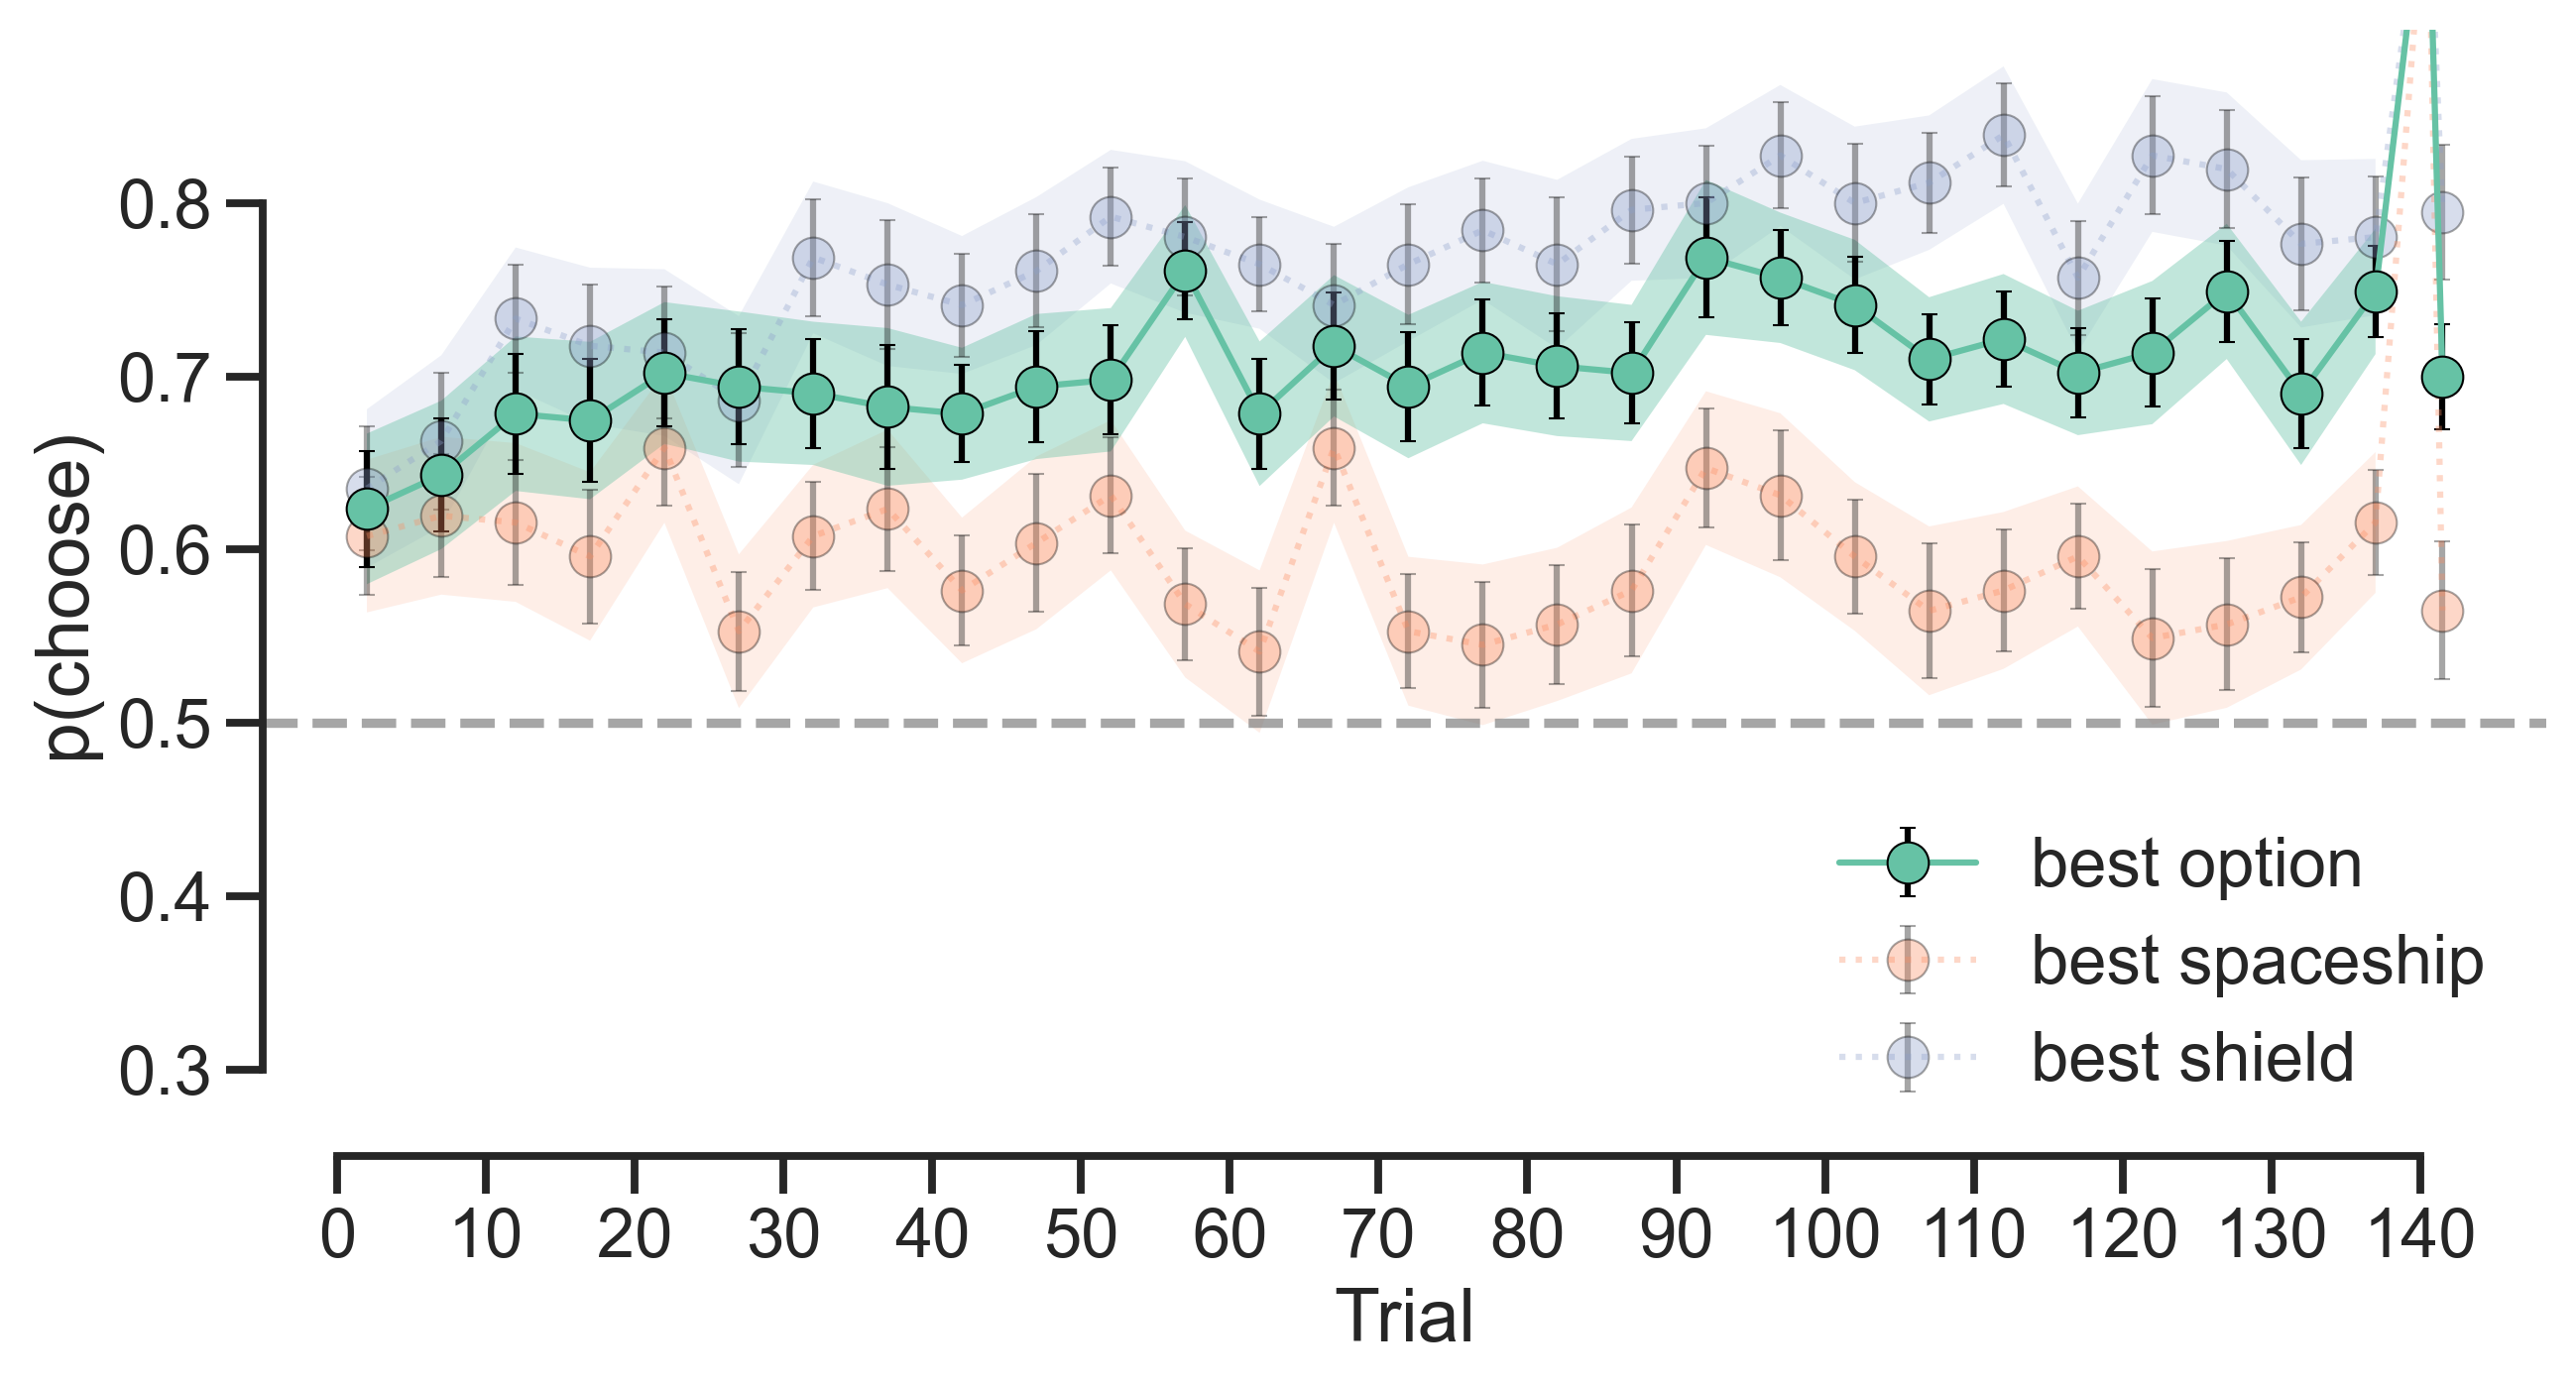

In [ ]:
# ========== FINAL PLOT WITH DOTS AND ERROR BARS ==========
import matplotlib.pyplot as plt
import seaborn as sns

# Filter and prepare data using df
data = df[(df.expName.isin(['exp1'])) & (df.session==3) & (df.pair.isin([0,1])) & (df.group!='random')].sort_values('t').copy()
# now set trials 1 to 144 for each prolificID using arange
data['t'] = data.groupby('prolificID').cumcount()
data = data.groupby(['prolificID', 't'], as_index=False).mean(numeric_only=True)

#

print(f"Data shape after filtering: {data.shape}")
print(f"Unique trials: {data['t'].nunique()}")
print(f"Unique subjects: {data['prolificID'].nunique()}")

def bin_trials2(data, bin_size=3):
    """Bin trials by averaging every bin_size trials"""
    binned_data = []
    for subject in data['prolificID'].unique():
        subject_data = data[data['prolificID'] == subject].copy()
        subject_data = subject_data.sort_values('t')
        
        # Create bins
        n_trials = len(subject_data)
        n_bins = int(np.ceil(n_trials / bin_size))  # Use ceil to include partial bins
        
        for i in range(n_bins):
            start_idx = i * bin_size
            end_idx = min((i + 1) * bin_size, n_trials)
            bin_data = subject_data.iloc[start_idx:end_idx]
            
            # Calculate mean values for this bin
            binned_trial = {
                'prolificID': subject,
                't_bin': start_idx + (end_idx - start_idx) // 2,  # Center of actual bin
                'opti_ff': bin_data['opti_ff'].mean(),
                'opti_ss': bin_data['opti_ss'].mean(),
                'opti_ev': bin_data['opti_ev'].mean()
            }
            binned_data.append(binned_trial)
    
    return pd.DataFrame(binned_data)

def bin_trials3(data, bin_size=5):
    """Bin trials by averaging every bin_size trials"""
    binned_data = []
    for subject in data['prolificID'].unique():
        subject_data = data[data.prolificID == subject].copy()
        subject_data = subject_data.sort_values('t')
        
        n_trials = len(subject_data)
        n_bins = int(np.ceil(n_trials / bin_size))
        
        for i in range(n_bins):
            start_idx = i * bin_size
            end_idx = min((i + 1) * bin_size, n_trials)
            bin_data = subject_data.iloc[start_idx:end_idx]
            
            # Use actual trial numbers for the center
            binned_trial = {
                'prolificID': subject,
                't_bin': bin_data['t'].mean(),  # Use mean of actual trial numbers
                'opti_ff': bin_data['opti_ff'].mean(),
                'opti_ss': bin_data['opti_ss'].mean(),
                'opti_ev': bin_data['opti_ev'].mean()
            }
            binned_data.append(binned_trial)
    
    return pd.DataFrame(binned_data)

def bin_trials(data, bin_size=5):
    """Bin trials by averaging every bin_size trials"""
    binned_data = []
    for subject in data['prolificID'].unique():
        subject_data = data[data.prolificID == subject].copy()
        subject_data = subject_data.sort_values('t')
        
        n_trials = len(subject_data)
        n_bins = int(np.ceil(n_trials / bin_size))
        
        for i in range(n_bins):
            start_idx = i * bin_size
            end_idx = min((i + 1) * bin_size, n_trials)
            bin_data = subject_data.iloc[start_idx:end_idx]
            
            # Use actual trial numbers for the center - THIS IS THE KEY FIX
            binned_trial = {
                'prolificID': subject,
                't_bin': bin_data['t'].mean(),  # ← Use mean of actual 't' values
                'opti_ff': bin_data['opti_ff'].mean(),
                'opti_ss': bin_data['opti_ss'].mean(),
                'opti_ev': bin_data['opti_ev'].mean()
            }
            binned_data.append(binned_trial)
    
    return pd.DataFrame(binned_data)

# Create binned dataset
data_binned = bin_trials(data, bin_size=5)
print(f"Reduced from {data['t'].nunique()} to {data_binned['t_bin'].nunique()} time points")

# Calculate means, SEM, and STD for each condition and time bin
def calculate_stats(data, y_col):
    stats = data.groupby('t_bin')[y_col].agg(['mean', 'sem', 'std']).reset_index()
    return stats

stats_ff = calculate_stats(data_binned, 'opti_ff')
stats_ss = calculate_stats(data_binned, 'opti_ss')
stats_ev = calculate_stats(data_binned, 'opti_ev')

# Create the final plot with dots, error bars, and fill
plt.figure(figsize=(9, 5), dpi=300)
sns.set_context('talk')
# Colors for each condition
colors = {'ff': 'C2', 'ss': 'C1', 'ev': 'C0'}
labels = {'ff': 'best shield', 'ss': 'best spaceship', 'ev': 'best option'}

# Plot each condition with different linestyles and alpha
for stats, condition in [(stats_ff, 'ff'), (stats_ss, 'ss'), (stats_ev, 'ev')]:
    color = colors[condition]
    label = labels[condition]
    
    # Set linestyle: dotted for ff and ss, solid for ev
    linestyle = ':' if condition in ['ff', 'ss'] else '-'
    
    # Set alpha: lower for ff and ss (0.5), normal for ev (1.0)
    alpha = 0.35 if condition in ['ff', 'ss'] else 1.0
    
    # Plot dots with SEM error bars and black edges
    plt.errorbar(stats['t_bin'], stats['mean'], yerr=stats['sem'], 
                 fmt='o', color=color, markersize=10, capsize=2, 
                 capthick=1, label=label, linewidth=1.5, linestyle=linestyle,
                 markeredgecolor='black', markeredgewidth=0.5, ecolor='black',
                 alpha=alpha)
    
    # Add SEM fill with alpha=0.2 (even more transparent for ff and ss)
    fill_alpha = 0.15 if condition in ['ff', 'ss'] else 0.4
    
    plt.fill_between(stats['t_bin'], 
                     stats['mean'] - stats['sem'] - 0.01, 
                     stats['mean'] + stats['sem'] + 0.01, 
                     color=color, alpha=fill_alpha, linewidth=0)

# Add horizontal reference line
plt.axhline(y=0.5, color='grey', linestyle='--', alpha=0.7)
plt.ylabel('p(choose)')
plt.xlabel('Trial')

# Set x-axis ticks and y-axis limits
plt.xticks(np.arange(0, 144, 10))
plt.ylim(.25, .9)

handles, labels = plt.gca().get_legend_handles_labels()
# Add a legend
plt.legend(title='', loc='lower right', frameon=False, handles=handles[::-1], labels=labels[::-1])

sns.despine(trim=True)

plt.tight_layout()

# Add mean values at the end for all three conditions
mean_ss = data.groupby(['prolificID'])['opti_ss'].mean().mean()
mean_ff = data.groupby(['prolificID'])['opti_ff'].mean().mean()
mean_ev = data.groupby(['prolificID'])['opti_ev'].mean().mean()

print(f"\n📊 MEAN PERFORMANCE:")
print(f"Shield (C2): {mean_ff:.3f}")
print(f"Spaceship (C1): {mean_ss:.3f}")
print(f"Combined (C0): {mean_ev:.3f}")

print("✅ Plot now shows dots with error bars and reduced data points!")


Rolling stats shape: (29, 4)
Trial range: 5.0 to 144.0


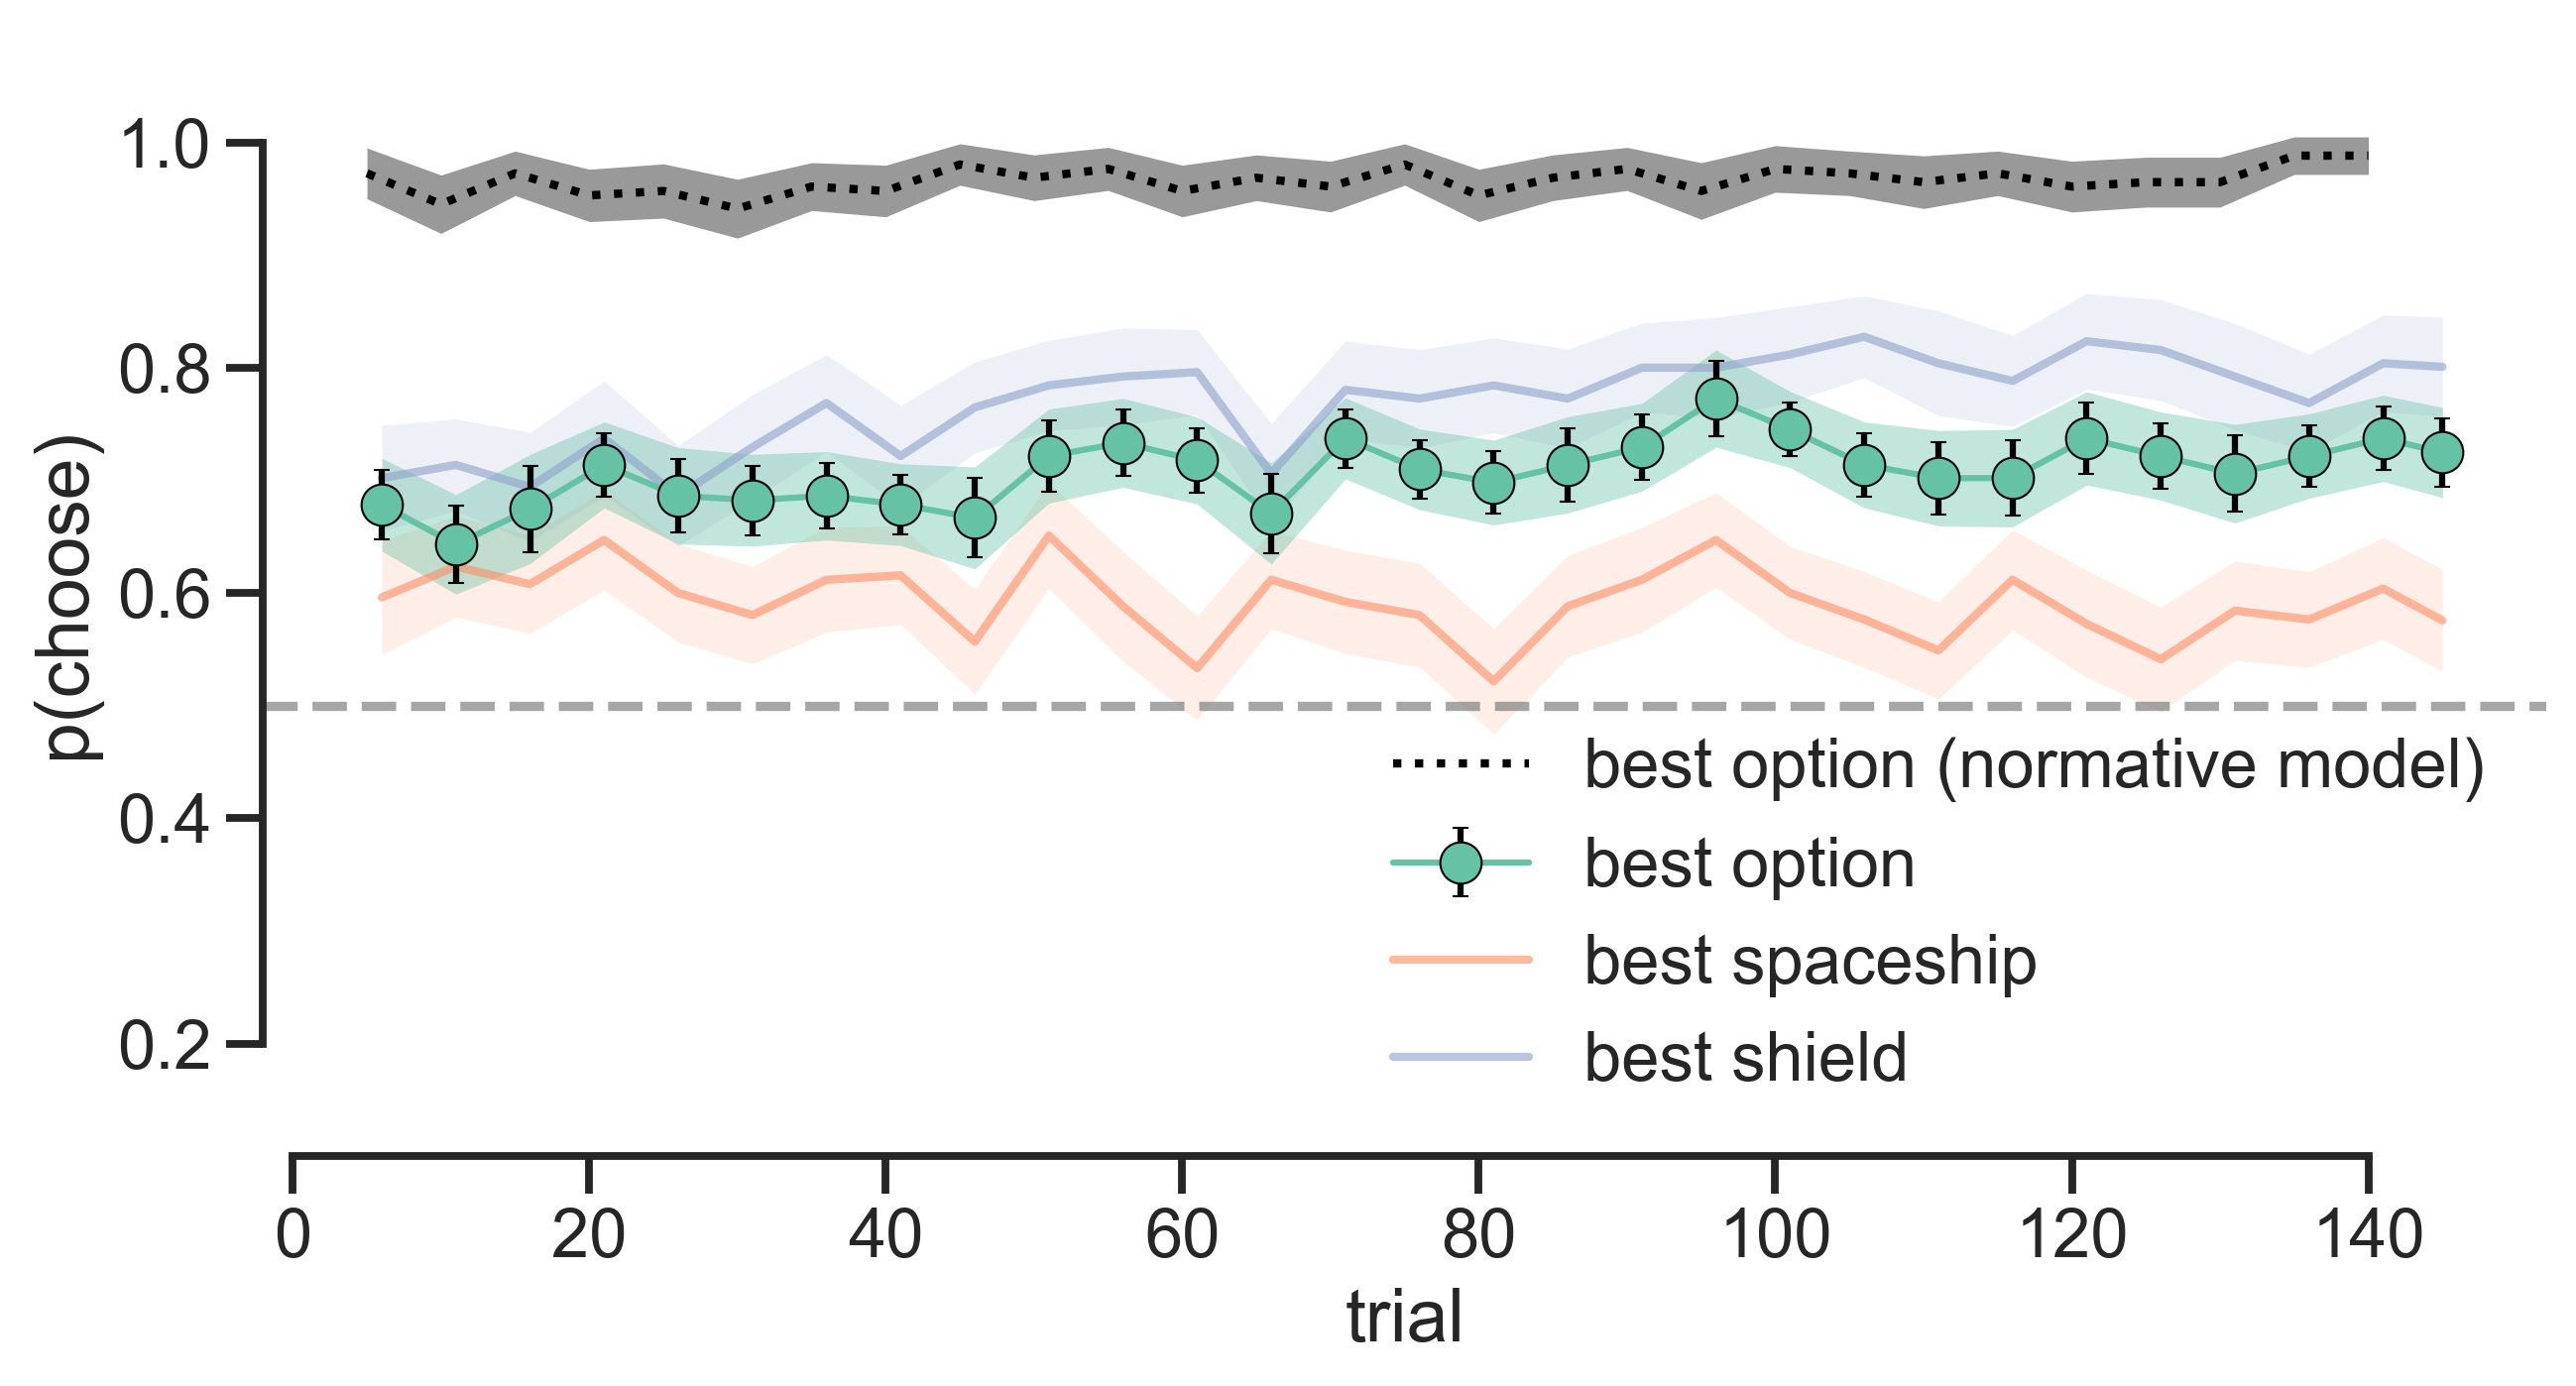

In [ ]:
# Simple rolling average approach - no custom binning needed
import pandas as pd
import numpy as np

df_sim = pd.read_csv('df_sim.csv')
df_sim = df_sim[(df_sim.session==3) & (df_sim.pair.isin([0,1])) & (df_sim.group!='random')].sort_values('t').copy()
df_sim['t'] = df_sim.groupby('prolificID').cumcount()
df_sim['model'] = 'normative'
# Your existing filtering
data = df[(df.expName.isin(['exp1'])) & (df.session==3) & (df.pair.isin([0,1])) & (df.group!='random')].sort_values('t').copy()
data['t'] = data.groupby('prolificID').cumcount()
data['model'] = 'human'
data = pd.concat([data, df_sim])
# data = data[data.model=='human']
# Calculate rolling means per subject, then average across subjects
bin_size = 5


# Group by subject and apply rolling mean
data_rolling = data[data.model=='human'].groupby(['prolificID'])[['t', 'opti_ff', 'opti_ss', 'opti_ev']].rolling(
    window=bin_size, 
    center=True,
    min_periods=1,
).mean().reset_index()

data_rolling2 = data[data.model=='normative'].groupby(['prolificID'])[['t', 'opti_ev']].rolling(
    window=bin_size,
    center=True,
    min_periods=1,
).mean().reset_index()

# now add data_rolling2 to data_rolling but opti_ev is renamed to normative_model
data_rolling = data_rolling.merge(data_rolling2[['prolificID', 't', 'opti_ev']], on=['prolificID', 't'], suffixes=('', '_normative'))   



# Select every 5th trial
stats_ff = data_rolling[data_rolling['t'] % bin_size == 0].groupby('t')['opti_ff'].agg(['mean', 'sem', 'std']).reset_index()
stats_ss = data_rolling[data_rolling['t'] % bin_size == 0].groupby('t')['opti_ss'].agg(['mean', 'sem', 'std']).reset_index()
stats_ev = data_rolling[data_rolling['t'] % bin_size == 0].groupby('t')['opti_ev'].agg(['mean', 'sem', 'std']).reset_index()
# Append the mean of the last 5 rows as trial 144
stats_ff.loc[len(stats_ff)] = [144, stats_ff.tail(5)['mean'].mean(), stats_ff.tail(5)['sem'].mean(), stats_ff.tail(5)['std'].mean()]
stats_ss.loc[len(stats_ss)] = [144, stats_ss.tail(5)['mean'].mean(), stats_ss.tail(5)['sem'].mean(), stats_ss.tail(5)['std'].mean()]
stats_ev.loc[len(stats_ev)] = [144, stats_ev.tail(5)['mean'].mean(), stats_ev.tail(5)['sem'].mean(), stats_ev.tail(5)['std'].mean()]

print(f"\nRolling stats shape: {stats_ff.shape}")
print(f"Trial range: {stats_ff['t'].min()} to {stats_ff['t'].max()}")
stats_ff['t'] = stats_ff['t'] + 1
stats_ss['t'] = stats_ss['t'] + 1
stats_ev['t'] = stats_ev['t'] + 1
stats_normative = data_rolling[data_rolling['t'] % bin_size == 0].groupby('t')['opti_ev_normative'].agg(['mean', 'sem', 'std']).reset_index()
# Create the final plot with dots, error bars, and fill
plt.figure(figsize=(9, 5), dpi=300)
sns.set_context('talk')
# Colors for each condition
colors = {'ff': 'C2', 'ss': 'C1', 'ev': 'C0', 'normative': 'C3'}
labels = {'ff': 'best shield', 'ss': 'best spaceship', 'ev': 'best option', 'normative': 'best option (normative model)'}

# Plot each condition with different linestyles and alpha
for stats, condition in [(stats_ff, 'ff'), (stats_ss, 'ss'), (stats_ev, 'ev'), (stats_normative, 'normative')]:
    color = colors[condition]
    label = labels[condition]
    
    # Set linestyle: dotted for ff and ss, solid for ev
    linestyle = '-' if condition in ['ff', 'ss', 'ev'] else ':' if condition == 'normative' else '-'
    
    # Set alpha: lower for ff and ss (0.5), normal for ev (1.0)
    alpha = .6 if condition in ['ff', 'ss'] else 1.0
    
    # Plot dots with SEM error bars and black edges
    if condition in ('ff', 'ss', 'normative'):
        color = {'ff': 'C2', 'ss': 'C1', 'normative': 'black'}[condition]
        plt.plot(stats['t'], stats['mean'], color=color, label=label, linewidth=2, linestyle=linestyle, alpha=alpha)
    else:
        plt.errorbar(stats['t'], stats['mean'], yerr=stats['sem'], 
                 fmt='o', color=color, markersize=10, capsize=2, 
                 capthick=1, label=label, linewidth=1.5, linestyle=linestyle,
                 markeredgecolor='black', markeredgewidth=0.5, ecolor='black',
                 alpha=alpha)
    
    # Add SEM fill with alpha=0.2 (even more transparent for ff and ss)
    fill_alpha = 0.15 if condition in ['ff', 'ss'] else 0.4
    
    plt.fill_between(stats['t'], 
                     stats['mean'] - stats['sem'] - 0.01, 
                     stats['mean'] + stats['sem'] + 0.01, 
                     color=color, alpha=fill_alpha, linewidth=0)

# Add horizontal reference line
plt.axhline(y=0.5, color='grey', linestyle='--', alpha=0.7)
plt.ylabel('p(choose)')
plt.xlabel('trial')

# Set x-axis ticks and y-axis limits
# plt.xticks(np.arange(0, 144, bin_size))
plt.ylim(.1, 1.1)
# plt.xticks(np.arange(5, 146, bin_size*2), np.arange(0, 145, bin_size*2))
handles, labels = plt.gca().get_legend_handles_labels()
# Add a legend
labels = labels[::-1]
labels = [labels[1], labels[0], labels[2], labels[3]]
handles = handles[::-1]
handles = [handles[1], handles[0], handles[2], handles[3]]
plt.legend(title='', loc='lower right', frameon=False, handles=handles, labels=labels)

sns.despine(trim=True)

plt.tight_layout()


Rolling stats shape: (29, 4)
Trial range: 5.0 to 144.0


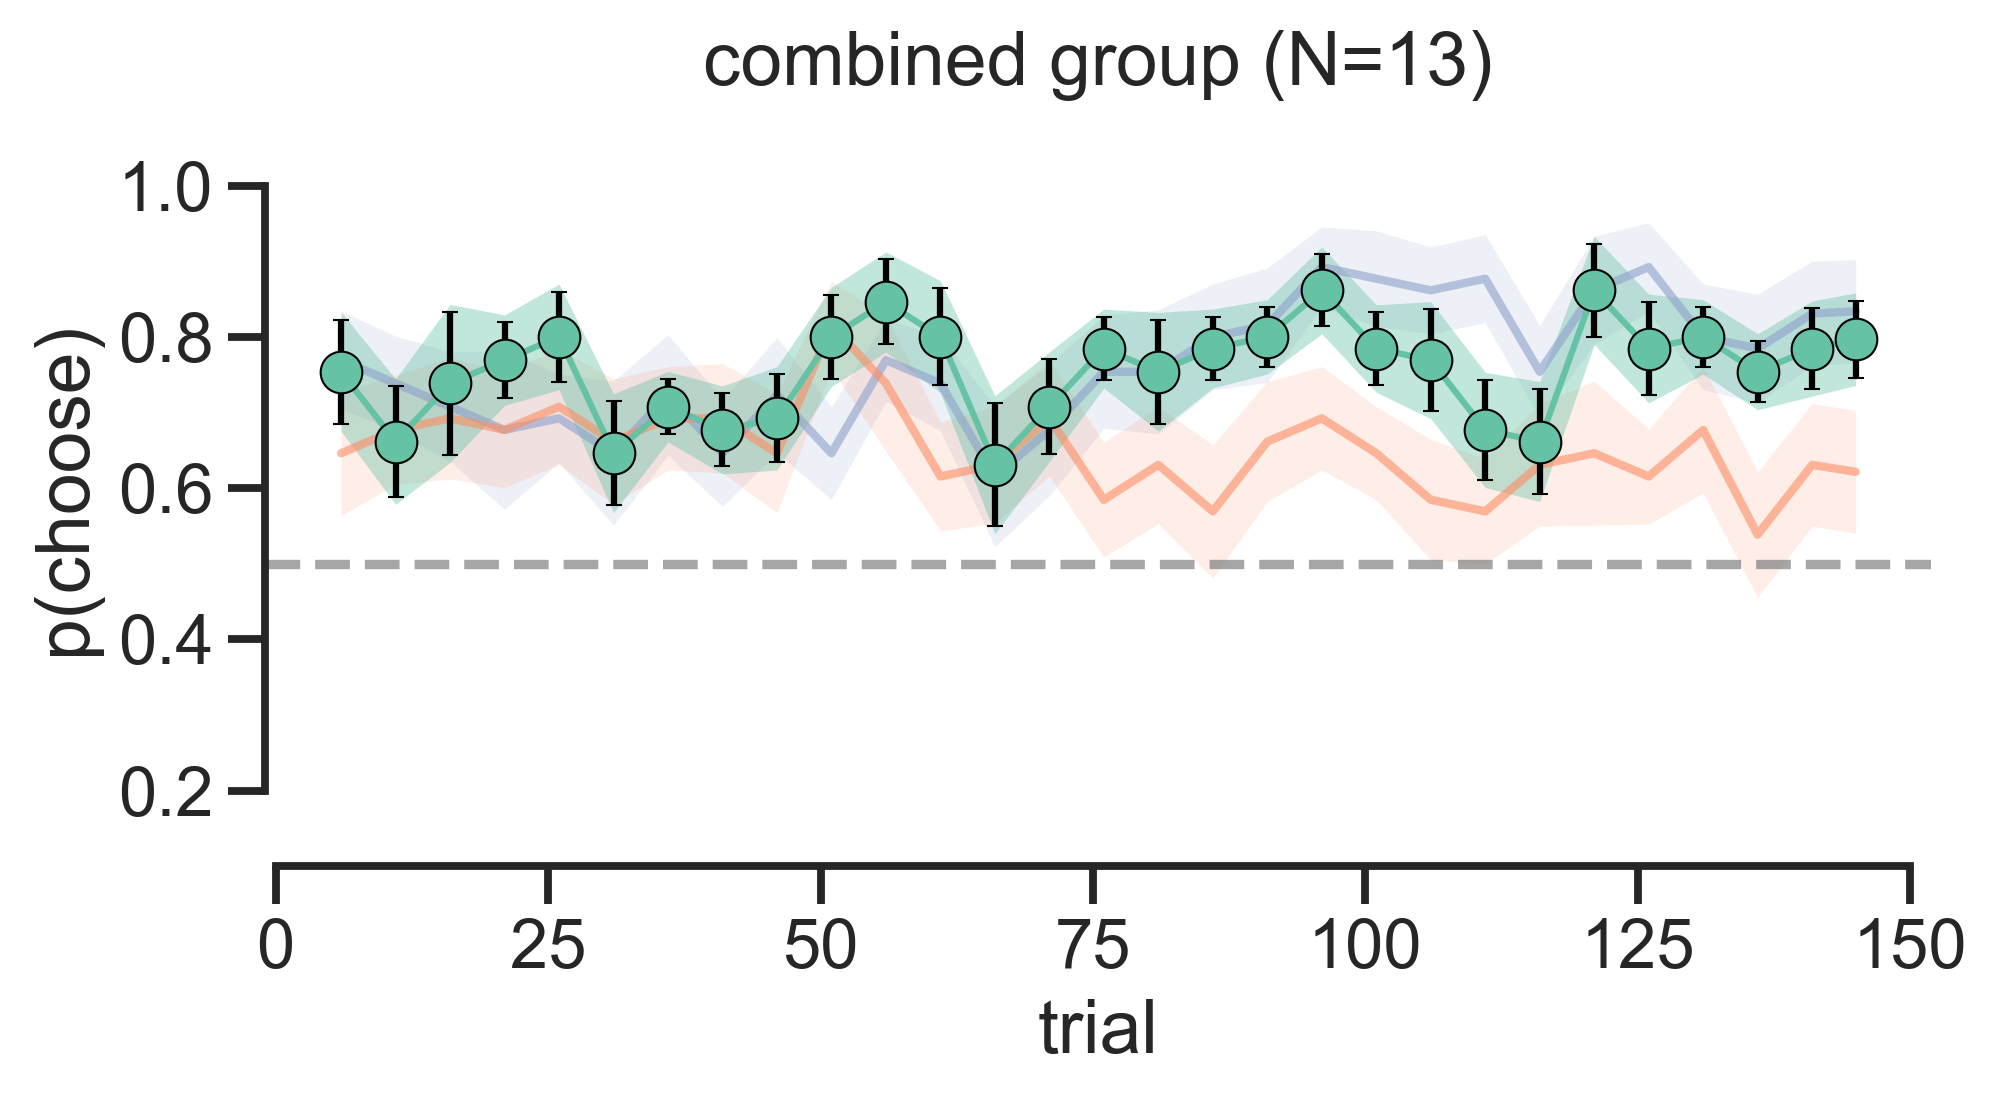

In [ ]:
# Simple rolling average approach - no custom binning needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

group = 'combined'
N = {'perceptual': 31, 'value': 7, 'combined': 13}
data = df[(df.expName.isin(['exp1'])) & (df.session==3) & (df.pair.isin([0,1])) & (df.group!='random') & (df.group2==group)].sort_values('t').copy()
data['t'] = data.groupby('prolificID').cumcount()

bin_size = 5


# Group by subject and apply rolling mean
data_rolling = data.groupby(['prolificID'])[['t', 'opti_ff', 'opti_ss', 'opti_ev']].rolling(
    window=bin_size, 
    center=True,
    min_periods=1,
).mean().reset_index()

# data_rolling2 = data[data.model=='normative'].groupby(['prolificID'])[['t', 'opti_ev']].rolling(
#     window=bin_size,
#     center=True,
#     min_periods=1,
# ).mean().reset_index()

# now add data_rolling2 to data_rolling but opti_ev is renamed to normative_model
# data_rolling = data_rolling.merge(data_rolling2[['prolificID', 't', 'opti_ev']], on=['prolificID', 't'], suffixes=('', '_normative'))   



# Select every 5th trial
stats_ff = data_rolling[data_rolling['t'] % bin_size == 0].groupby('t')['opti_ff'].agg(['mean', 'sem', 'std']).reset_index()
stats_ss = data_rolling[data_rolling['t'] % bin_size == 0].groupby('t')['opti_ss'].agg(['mean', 'sem', 'std']).reset_index()
stats_ev = data_rolling[data_rolling['t'] % bin_size == 0].groupby('t')['opti_ev'].agg(['mean', 'sem', 'std']).reset_index()
# Append the mean of the last 5 rows as trial 144
stats_ff.loc[len(stats_ff)] = [144, stats_ff.tail(5)['mean'].mean(), stats_ff.tail(5)['sem'].mean(), stats_ff.tail(5)['std'].mean()]
stats_ss.loc[len(stats_ss)] = [144, stats_ss.tail(5)['mean'].mean(), stats_ss.tail(5)['sem'].mean(), stats_ss.tail(5)['std'].mean()]
stats_ev.loc[len(stats_ev)] = [144, stats_ev.tail(5)['mean'].mean(), stats_ev.tail(5)['sem'].mean(), stats_ev.tail(5)['std'].mean()]

print(f"\nRolling stats shape: {stats_ff.shape}")
print(f"Trial range: {stats_ff['t'].min()} to {stats_ff['t'].max()}")
stats_ff['t'] = stats_ff['t'] + 1
stats_ss['t'] = stats_ss['t'] + 1
stats_ev['t'] = stats_ev['t'] + 1
# stats_normative = data_rolling[data_rolling['t'] % bin_size == 0].groupby('t')['opti_ev_normative'].agg(['mean', 'sem', 'std']).reset_index()
# Create the final plot with dots, error bars, and fill
plt.figure(figsize=(7, 4), dpi=300)
sns.set_context('talk')
# Colors for each condition
colors = {'ff': 'C2', 'ss': 'C1', 'ev': 'C0', 'normative': 'C3'}
labels = {'ff': 'best shield', 'ss': 'best spaceship', 'ev': 'best option', 'normative': 'best option (normative model)'}

# Plot each condition with different linestyles and alpha
for stats, condition in [(stats_ff, 'ff'), (stats_ss, 'ss'), (stats_ev, 'ev')]:
    color = colors[condition]
    label = labels[condition]
    
    # Set linestyle: dotted for ff and ss, solid for ev
    linestyle = '-' if condition in ['ff', 'ss', 'ev'] else ':' if condition == 'normative' else '-'
    
    # Set alpha: lower for ff and ss (0.5), normal for ev (1.0)
    alpha = .6 if condition in ['ff', 'ss'] else 1.0
    
    # Plot dots with SEM error bars and black edges
    if condition in ('ff', 'ss', 'normative'):
        color = {'ff': 'C2', 'ss': 'C1', 'normative': 'black'}[condition]
        plt.plot(stats['t'], stats['mean'], color=color, label=label, linewidth=2, linestyle=linestyle, alpha=alpha)
    else:
        plt.errorbar(stats['t'], stats['mean'], yerr=stats['sem'], 
                 fmt='o', color=color, markersize=10, capsize=2, 
                 capthick=1, label=label, linewidth=1.5, linestyle=linestyle,
                 markeredgecolor='black', markeredgewidth=0.5, ecolor='black',
                 alpha=alpha)
    
    # Add SEM fill with alpha=0.2 (even more transparent for ff and ss)
    fill_alpha = 0.15 if condition in ['ff', 'ss'] else 0.4
    
    plt.fill_between(stats['t'], 
                     stats['mean'] - stats['sem'] - 0.01, 
                     stats['mean'] + stats['sem'] + 0.01, 
                     color=color, alpha=fill_alpha, linewidth=0)

# Add horizontal reference line
plt.axhline(y=0.5, color='grey', linestyle='--', alpha=0.7)
plt.ylabel('p(choose)')
plt.xlabel('trial')

# Set x-axis ticks and y-axis limits
# plt.xticks(np.arange(0, 144, bin_size))
plt.ylim(.1, 1.1)
# plt.xticks(np.arange(5, 146, bin_size*2), np.arange(0, 145, bin_size*2))
handles, labels = plt.gca().get_legend_handles_labels()
# Add a legend
labels = labels[::-1]
# labels = [labels[1], labels[0], labels[2]]
handles = handles[::-1]
# handles = [handles[1], handles[0], handles[2]]
plt.legend(title='', loc='lower right', frameon=False, handles=handles, labels=labels, bbox_to_anchor=(1, 2))
plt.legend().remove()
sns.despine(trim=True)

plt.title(group + ' group (N=' + str(len(data.prolificID.unique())) + ')')

plt.tight_layout()

In [ ]:
df2 = df[(df.expName=='exp1') & (df.session==3)].groupby(['prolificID', 'group'], as_index=False).mean(numeric_only=True)
df_fit2 = df_fit[(df_fit.exp=='exp1') & (df_fit.model=='map')]
df_fit2['opti_ff'] = df2.set_index('prolificID').loc[df_fit2.prolificID].opti_ff.values
df_fit2['opti_ss'] = df2.set_index('prolificID').loc[df_fit2.prolificID].opti_ss.values
df_fit2['delta'] = df_fit2.opti_ff - df_fit2.opti_ss
df_fit2['opti_ev'] = df2.set_index('prolificID').loc[df_fit2.prolificID].opti_ev.values

df_fit2['group'] = df2.set_index('prolificID').loc[df_fit2.prolificID].group.values



In [ ]:
data = data[data.exp=='exp3']
# count how many subjects are best fitted by each model using the lowest log likelihood
data['BIC'] = 2 * data['ll'] + 2 * np.log(data['ntrials'])

best_models = data.groupby('prolificID').apply(lambda x: x.loc[x['BIC'].idxmin()]).reset_index(drop=True)
# Count the number of participants for each model
model_counts = best_models['model'].value_counts().reset_index()
model_counts.columns = ['model', 'count']
# Print the counts
print(model_counts)

        model  count
0         map     45
1  perceptual     16
2       value      4


C:\Users\garciaba\AppData\Local\Temp\ipykernel_24764\1899969539.py:20: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.violinplot(data=data, x="model", y="BIC", palette=palette, split=True, gap=0.3,


NameError: name 'd_' is not defined

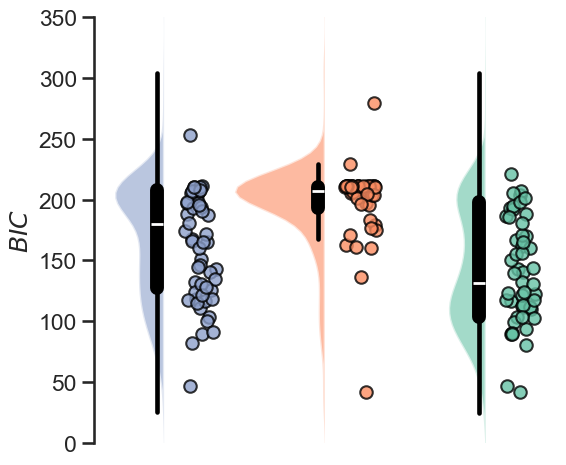

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# --- Prepare plot --- #
sns.set({'figure.figsize': (6, 5)})
sns.set_context('talk')
sns.set_style('ticks')
sns.set_palette('Set2')
palette = ['C2', 'C1', 'C0']
order = ['perceptual', 'value', 'map']

group_positions = {g: i for i, g in enumerate(order)}
group_names = order

df = data[(data.group!='random') & (data.exp=='exp1')].copy()
# --- Violin plots --- #
sns.violinplot(data=data, x="model", y="BIC", palette=palette, split=True, gap=0.3,
               hue=True, hue_order=[True, False], alpha=.6, linecolor='w', zorder=0,
                 inner_kws={'color': 'black', 'box_width': 10}, inner='box', order=order)


# --- Manually set half violin colors --- #
ax = plt.gca()
plt.xlabel('')
plt.ylabel('$BIC$')
plt.ylim(0, 350)
# remove xticks labels 
plt.xticks(range(len(group_names)), [''] * len(group_names), rotation=0)
for i, collection in enumerate(ax.collections):
    if hasattr(collection, 'get_paths') and len(collection.get_paths()) > 0:
        # This is a violin body
        violin_idx = i # Each violin has 2 collections (left and right halves)
        if violin_idx < len(palette):
            collection.set_facecolor(palette[violin_idx])
            collection.set_alpha(0.6)

# --- Stripplot with controlled jitter --- #
jitter_strength = 0.1
bias_to_right = .5
dot_coords = []  # store jittered (x, y, subject)

for i, group in enumerate(group_names):
    subset = df[df["model"] == group]
    jittered_x = i + np.random.uniform(-jitter_strength, jitter_strength, size=len(subset))
    jittered_x += bias_to_right
    y_vals = subset["BIC"].values
    subj_ids = subset["prolificID"].values

    # if the max value overall is detected, set ax
    if df["BIC"].max() in y_vals:
        plt.scatter(jittered_x, y_vals, color=palette[i], alpha=0.8, zorder=3, edgecolors='black')
    else:
        plt.scatter(jittered_x, y_vals, color=palette[i], alpha=0.8, zorder=3, edgecolors='black')

    # Save jittered coordinates and subjects
    for x, y, s in zip(jittered_x, y_vals, subj_ids):
        dot_coords.append({"subject": s, "group": group, "x": x, "y": y})


# --- Aesthetics --- #
bias_x_axis = 0.25
# plt.title("Raincloud Plot with Controlled Jitter & Connections", fontsize=14)
# plt.xticks(range(len(group_names)), [1, 2, 3])
# plt.xticks([i + bias_x_axis for i in range(len(group_names))], [''], rotation=0)

sns.despine(bottom=True)
plt.tick_params(axis='x', which='both', bottom=False, top=False)

# the y axis ticks should only show from 0 to 1
# plt.yticks(np.arange(0, 1.1, 0.2))
# add horizontal line at y=0.5
# plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, zorder=1)
sns.despine(trim=True, bottom=True)
plt.tight_layout()
plt.legend().remove()

from statannotations.Annotator import Annotator
import itertools

# Create pairs of experiments for annotation
pairs = list(itertools.combinations(order, 2))
annotator = Annotator(ax,  pairs, x='model', y='BIC',
                     data=data, order=order)
# annotator.configure(test='t-test_ind', text_format='star', loc='outside').apply_test()
# test should be mann-whitney u test
annotator.configure(test='t-test_paired', text_format='star', loc='outside').apply_test()

annotator.annotate_custom_annotations([s[:-1] + f' $d={d:.2f}$' for s, d in zip(annotator.get_annotations_text(), d_)])




C:\Users\basil\AppData\Local\Temp\ipykernel_5588\2005350497.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.pointplot(x='model', y='BIC', data=data, join=False, errorbar='se',
C:\Users\basil\AppData\Local\Temp\ipykernel_5588\2005350497.py:24: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(x='model', y='BIC', data=data, join=False, errorbar='se',
C:\Users\basil\AppData\Local\Temp\ipykernel_5588\2005350497.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='model', y='BIC', data=data, palette=palette, alpha=0.6, ax=ax, order=order,


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

perceptual vs. value: **** $d=0.94$
value vs. map: **** $d=1.28$
perceptual vs. map: *** $d=0.32$
perceptual - t-statistic: 11.685, p-value: 0.000
value - t-statistic: 28.017, p-value: 0.000
map - t-statistic: 8.722, p-value: 0.000


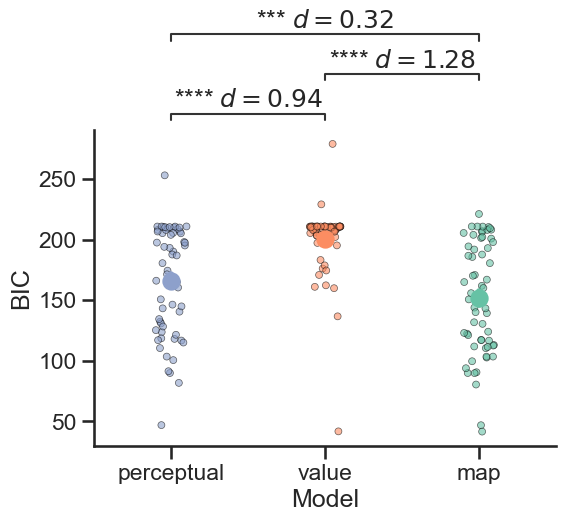

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator
import itertools
import pingouin as pg
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests

# --- Setup --- #
sns.set({"figure.figsize": (6, 6), 'figure.dpi': 100})
sns.set_style("ticks")
sns.set_context("talk")
sns.set_palette("Set2")

palette = ['C2', 'C1', 'C0']
order = ['perceptual', 'value', 'map']

# --- Data preparation --- #
data = df_fit[df_fit.exp == 'exp1'].groupby(['model', 'prolificID']).last().reset_index()

# --- Plot --- #
ax = sns.pointplot(x='model', y='BIC', data=data, join=False, errorbar='se',
                   palette=palette, order=order, zorder=10)
sns.stripplot(x='model', y='BIC', data=data, palette=palette, alpha=0.6, ax=ax, order=order,
              edgecolor='black', linewidth=0.5)

plt.xlabel('Model')
plt.ylabel('BIC')
sns.despine()

# --- Statistical annotations (paired t-test) --- #
pairs = list(itertools.combinations(order, 2))
annotator = Annotator(ax, pairs, x='model', y='BIC', data=data, order=order)
annotator.configure(test='t-test_paired', text_format='star', loc='outside').apply_test()

# --- Effect size computation (Cohen's d) --- #
d_ = []
for (i, j) in pairs:
    d = pg.compute_effsize(data[data.model == i]['BIC'],
                           data[data.model == j]['BIC'],
                           eftype='cohen', paired=True)  # use paired=True since it's the same subjects
    d_.append(abs(d))

annotator.annotate_custom_annotations(
    [s + f' $d={d:.2f}$' for s, d in zip(annotator.get_annotations_text(), d_)]
)

# --- One-sample t-tests against a reference value (optional, e.g., test vs. mean BIC=100) --- #
bic_reference = 100
for model in order:
    group_data = data[data.model == model]['BIC']
    t_stat, p_value = stats.ttest_1samp(group_data, bic_reference)
    _, p_value_corrected, _, _ = multipletests([p_value], method='bonferroni')
    p_value = p_value_corrected[0]
    print(f"{model} - t-statistic: {t_stat:.3f}, p-value: {p_value:.3f}")

plt.tight_layout()


C:\Users\basil\AppData\Local\Temp\ipykernel_23704\609557740.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.pointplot(x='exp', y='omega', data=data, join=False, errorbar='se',
C:\Users\basil\AppData\Local\Temp\ipykernel_23704\609557740.py:12: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  ax = sns.pointplot(x='exp', y='omega', data=data, join=False, errorbar='se',
C:\Users\basil\AppData\Local\Temp\ipykernel_23704\609557740.py:12: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(x='exp', y='omega', data=data, join=False, errorbar='se',
C:\Users\basil\AppData\Local\Temp\ipykernel_23704\609557740.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecate

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

FullPilot12 vs. FullPilot13: * $d=0.44$
FullPilot13 vs. FullPilot14: * $d=0.37$
FullPilot12 vs. FullPilot14: ns $d=0.09$


(<Axes: xlabel='model', ylabel='$\\omega$'>,
  <statannotations.Annotation.Annotation at 0x1a6b1476310>])

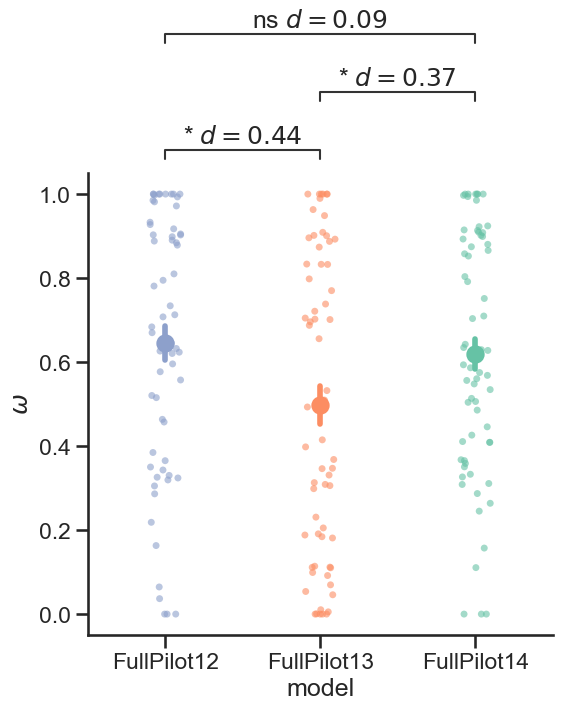

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

sns.set({    "figure.figsize": (6, 6), 'figure.dpi': 100})
sns.set_style("ticks")
sns.set_context("talk")
sns.set_palette("Set2")
order = ['exp1', 'exp2', 'exp3']
palette = ['C2', 'C1', 'C0', 'grey']
# data['outcome'] = data['outcome']*1000
data = df_fit[df_fit.model=='map'].groupby(['exp', 'prolificID']).last().reset_index()
ax = sns.pointplot(x='exp', y='omega', data=data, join=False, errorbar='se',
              palette=palette, order=order, zorder=10)
sns.stripplot(x='exp', y='omega', data=data, palette=palette, alpha=0.6,  ax=ax, order=order)
# plt.ylim(0.4, 1)
plt.xlabel('model')
sns.despine()
# plt.xticks([0, 1, 2], ['exp. 1', 'exp. 2', 'exp. 3'])
plt.ylabel('$\omega$')
from statannotations.Annotator import Annotator
import itertools

# Create pairs of experiments for annotation
pairs = list(itertools.combinations(order, 2))
annotator = Annotator(ax,  pairs, x='exp', y='omega',
                     data=data, order=order)
annotator.configure(test='t-test_ind', text_format='star', loc='outside').apply_test()

# compute effect size for each pair
import pingouin as pg
d_ = []
for (i, j) in pairs:
    d = pg.compute_effsize(data[data.exp == i]['omega'], data[data.exp == j]['omega'],
                     eftype='cohen', paired=False)
    d_.append(abs(d))

annotator.annotate_custom_annotations([s + f' $d={d:.2f}$' for s, d in zip(annotator.get_annotations_text(), d_)])

C:\Users\basil\AppData\Local\Temp\ipykernel_23704\2578188922.py:20: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.violinplot(data=data_, x="exp", y="omega", palette=palette, split=True, gap=0.3,


0.20851506515493115
0.06414664022242429
-0.18186411942195285
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

FullPilot12 vs. FullPilot13: * $d=0.44$
FullPilot13 vs. FullPilot14: * $d=0.37$
FullPilot12 vs. FullPilot14: ns $d=0.09$


(<Axes: xlabel='Experiment', ylabel='$\\omega$'>,
  <statannotations.Annotation.Annotation at 0x1a6c93c48e0>])

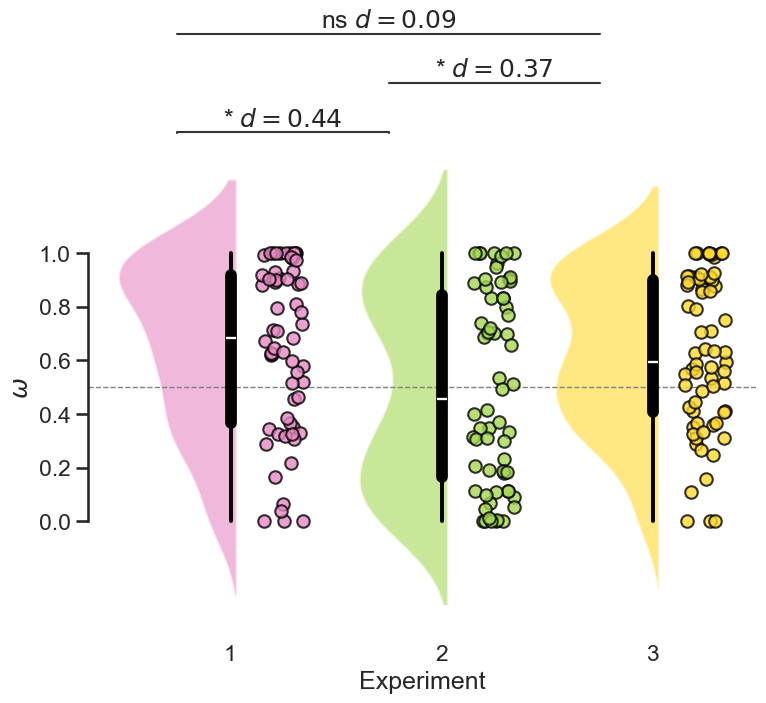

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# --- Prepare plot --- #
sns.set({'figure.figsize': (8, 6)})
sns.set_context('talk')
sns.set_style('ticks')
sns.set_palette('Set2')
palette = ['C3', 'C4', 'C5']
order = ['exp1', 'exp2', 'exp3']

group_positions = {g: i for i, g in enumerate(order)}
group_names = order

data_ = data[(data.group!='random') & (data.exp.isin(order))].copy()
# --- Violin plots --- #
sns.violinplot(data=data_, x="exp", y="omega", palette=palette, split=True, gap=0.3,
               hue=True, hue_order=[True, False], alpha=.6, linecolor='w', zorder=0,
                 inner_kws={'color': 'black', 'linewidth': 0.5}, inner='box')
# --- Manually set half violin colors --- #
ax = plt.gca()
plt.xlabel('Experiment')
plt.ylabel('$\omega$')

for i, collection in enumerate(ax.collections):
    if hasattr(collection, 'get_paths') and len(collection.get_paths()) > 0:
        # This is a violin body
        violin_idx = i # Each violin has 2 collections (left and right halves)
        if violin_idx < len(palette):
            collection.set_facecolor(palette[violin_idx])
            collection.set_alpha(0.6)

# --- Stripplot with controlled jitter --- #
jitter_strength = 0.1
bias_to_right = .5
dot_coords = []  # store jittered (x, y, subject)

for i, group in enumerate(order):
    subset = data_[data_["exp"] == group]
    jittered_x = i + np.random.uniform(-jitter_strength, jitter_strength, size=len(subset))
    jittered_x += bias_to_right
    y_vals = subset["omega"].values
    subj_ids = subset["prolificID"].values

    plt.scatter(jittered_x, y_vals, color=palette[i], alpha=0.8, zorder=3, edgecolors='black')

    # Save jittered coordinates and subjects
    for x, y, s in zip(jittered_x, y_vals, subj_ids):
        dot_coords.append({"subject": s, "group": group, "x": x, "y": y})


# --- Aesthetics --- #
bias_x_axis = 0.25
# plt.title("Raincloud Plot with Controlled Jitter & Connections", fontsize=14)
plt.xticks(range(len(order)), [''] * len(order), rotation=0)
plt.xticks([i + bias_x_axis for i in range(len(order))],[1,2,3], rotation=0)

sns.despine(bottom=True)
plt.tick_params(axis='x', which='both', bottom=False, top=False)

# the y axis ticks should only show from 0 to 1
plt.yticks(np.arange(0, 1.1, 0.2))
# add horizontal line at y=0.5
plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, zorder=1)
sns.despine(trim=True, bottom=True)
plt.tight_layout()
plt.legend().remove()

from statannotations.Annotator import Annotator
import itertools

# Create pairs of experiments for annotation
pairs = list(itertools.combinations(order, 2))
annotator = Annotator(ax,  pairs, x='exp', y='omega',
                     data=data, order=order)
# annotator.configure(test='t-test_ind', text_format='star', loc='outside').apply_test()
# test should be mann-whitney u test
annotator.configure(test='Mann-Whitney', text_format='star', loc='outside', line_height=0.001).apply_test()
# def compute_r_effsize(group1, group2):
#     """
#     Compute the rank-biserial correlation coefficient (r) for two groups.
#     """
#   # Calculate Z score from U
#     n1 = len(group1)
#     n2 = len(group2)
#     N = n1 + n2
#     # get the U 
#     import scipy.stats as stats
#     U, _ = stats.mannwhitneyu(group1, group2, alternative='two-sided')
#     # Mean and standard deviation of U
#     mean_U = n1 * n2 / 2
#     std_U = np.sqrt(n1 * n2 * (N + 1) / 12)

#     # Z-score
#     Z = (U - mean_U) / std_U

#     # Effect size
#     r = Z / np.sqrt(N)

#     return r
# compute effect size for each pair
import pingouin as pg
d_ = []
for (i, j) in pairs:
    d = pg.compute_effsize(data[data.exp == i]['omega'], data[data.exp == j]['omega'],
                     eftype='cohen', paired=False)
    # as it is a non-parametric test, use r instead of d
    #  rank-biserial correlation coefficient (r).
    # the thing is we have two groups with different number of subjects
    r = compute_r_effsize(
        data[data.exp == i]['omega'].values,
        data[data.exp == j]['omega'].values
    )

    print(r)
    
    d_.append(abs(d))

annotator.annotate_custom_annotations([s + f' $d={d:.2f}$' for s, d in zip(annotator.get_annotations_text(), d_)])

# import scipy.stats as stats
# # test each group against 0.5 with scipy.stats.ttest_1samp
# for group in order:
#     group_data = data[data.exp == group]['omega']
#     t_stat, p_value = stats.ttest_1samp(group_data, 0.5)
#     # correct for multiple comparison using scipy.stats.multitest
#     from statsmodels.stats.multitest import multipletests
#     _, p_value_corrected, _, _ = multipletests([p_value], method='bonferroni')
#     p_value = p_value_corrected[0]  
#     # print the t-statistic and p-value
  
#     print(f"{group} - t-statistic: {t_stat:.3f}, p-value: {p_value:.3f}")



In [ ]:
sns.color_palette('Set2')

[(0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 (0.9058823529411765, 0.5411764705882353, 0.7647058823529411),
 (0.6509803921568628, 0.8470588235294118, 0.32941176470588235),
 (1.0, 0.8509803921568627, 0.1843137254901961),
 (0.8980392156862745, 0.7686274509803922, 0.5803921568627451),
 (0.7019607843137254, 0.7019607843137254, 0.7019607843137254)]

C:\Users\basil\AppData\Local\Temp\ipykernel_23704\3355607597.py:20: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.violinplot(data=data_, x="exp", y="omega", palette=palette, split=True, gap=0.3,


Text(0.5, 129.24999999999997, '')

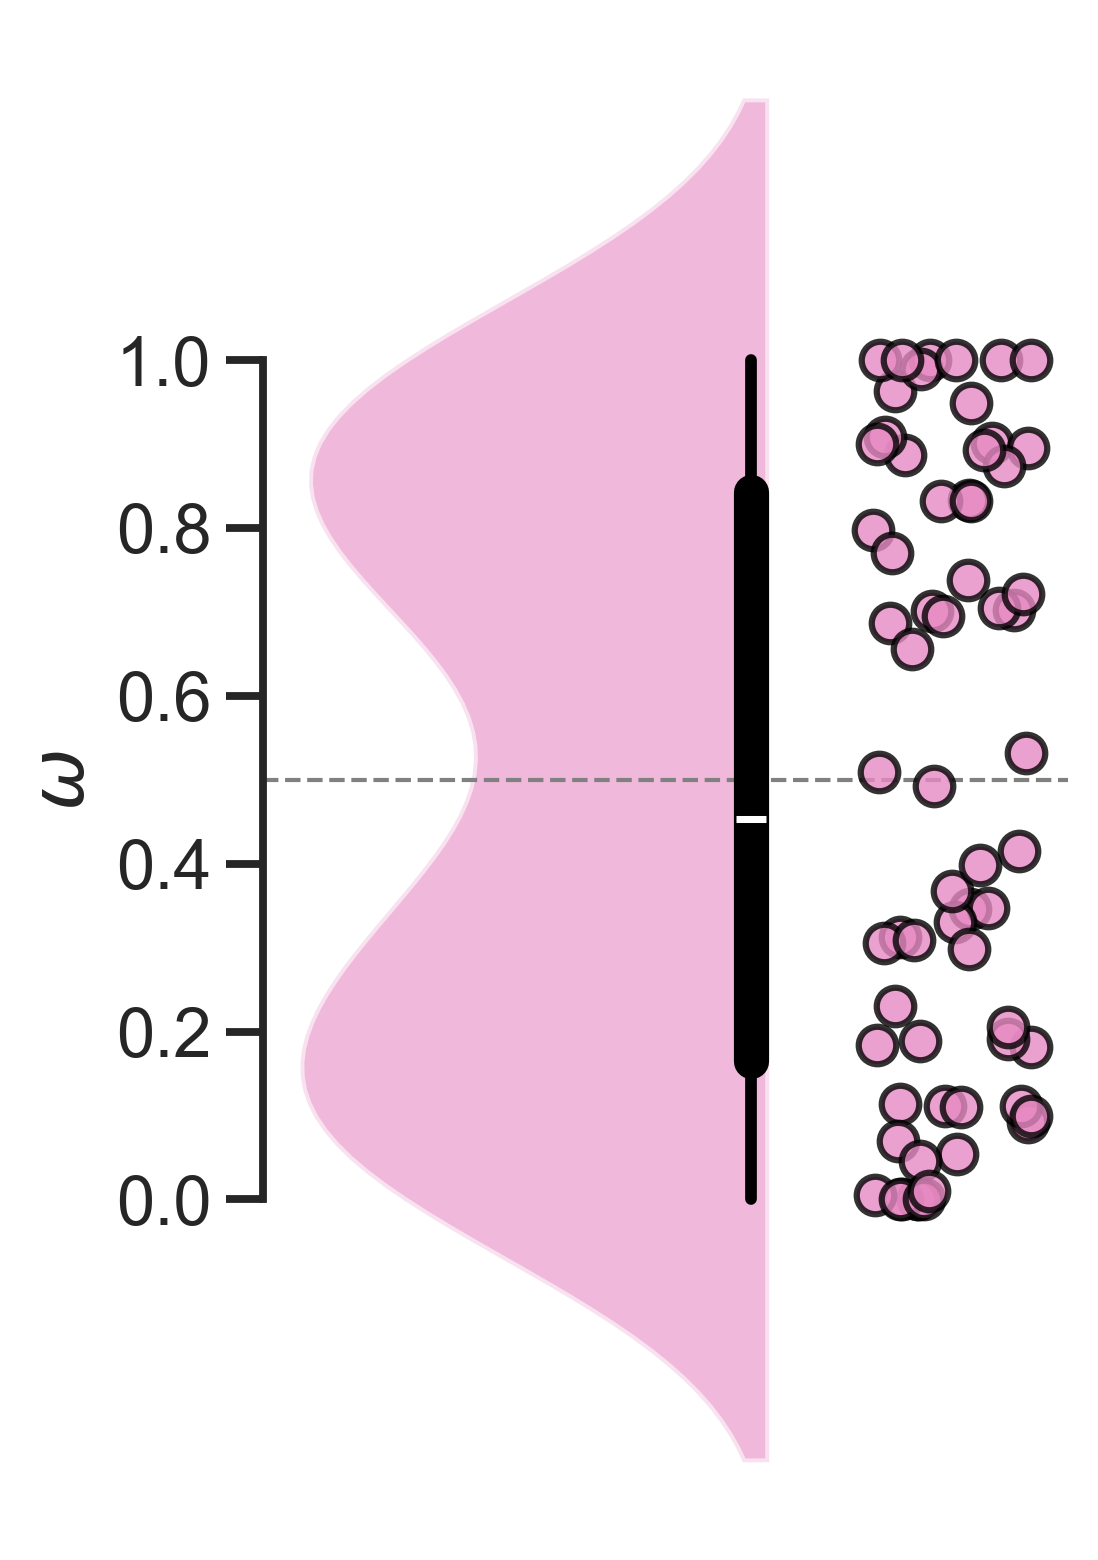

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# --- Prepare plot --- #
sns.set({'figure.figsize': (4, 6), 'figure.dpi': 300})
sns.set_context('talk')
sns.set_style('ticks')
sns.set_palette('Set2')
np.random.seed(42)
palette = ['C3', 'C1', 'C0']
order = [['exp1', 'exp2', 'exp3'][1]]
group_positions = {g: i for i, g in enumerate(order)}
group_names = order

data_ = data[(data.group!='random') & (data.exp.isin(order))].copy()
# --- Violin plots --- #
sns.violinplot(data=data_, x="exp", y="omega", palette=palette, split=True, gap=0.3,
               hue=True, hue_order=[True, False], alpha=.6, linecolor='w', zorder=0,
                 inner_kws={'color': 'black', 'linewidth': 0.5}, inner='box')
# --- Manually set half violin colors --- #
ax = plt.gca()
# plt.xlabel('Experiment')
plt.ylabel('$\omega$')

for i, collection in enumerate(ax.collections):
    if hasattr(collection, 'get_paths') and len(collection.get_paths()) > 0:
        # This is a violin body
        violin_idx = i # Each violin has 2 collections (left and right halves)
        if violin_idx < len(palette):
            collection.set_facecolor(palette[violin_idx])
            # collection.set_facecolor('white')
            collection.set_alpha(0.6)

# --- Stripplot with controlled jitter --- #
jitter_strength = 0.1
bias_to_right = .5
dot_coords = []  # store jittered (x, y, subject)

for i, group in enumerate(order):
    subset = data_[data_["exp"] == group]
    jittered_x = i + np.random.uniform(-jitter_strength, jitter_strength, size=len(subset))
    jittered_x += bias_to_right
    y_vals = subset["omega"].values
    subj_ids = subset["prolificID"].values

    plt.scatter(jittered_x, y_vals, color=palette[i], alpha=0.8, zorder=3, edgecolors='black')

    # Save jittered coordinates and subjects
    for x, y, s in zip(jittered_x, y_vals, subj_ids):
        dot_coords.append({"subject": s, "group": group, "x": x, "y": y})


# --- Aesthetics --- #
bias_x_axis = 0.25
# plt.title("Raincloud Plot with Controlled Jitter & Connections", fontsize=14)
plt.xticks(range(len(order)), [''] * len(order), rotation=0)
plt.xticks([i + bias_x_axis for i in range(len(order))], [''] * len(order), rotation=0)

sns.despine(bottom=True)
plt.tick_params(axis='x', which='both', bottom=False, top=False)

# the y axis ticks should only show from 0 to 1
plt.yticks(np.arange(0, 1.1, 0.2))
# add horizontal line at y=0.5
plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, zorder=1)
sns.despine(trim=True, bottom=True)
plt.tight_layout()
plt.legend().remove()
plt.xlabel('')

# from statannotations.Annotator import Annotator
# import itertools

# # Create pairs of experiments for annotation
# pairs = list(itertools.combinations(order, 2))
# annotator = Annotator(ax,  pairs, x='exp', y='omega',
#                      data=data, order=order)
# # annotator.configure(test='t-test_ind', text_format='star', loc='outside').apply_test()
# # test should be mann-whitney u test
# annotator.configure(test='Mann-Whitney', text_format='star', loc='outside').apply_test()

# def compute_r_effsize(group1, group2):
#     """
#     Compute the rank-biserial correlation coefficient (r) for two groups.
#     """
#   # Calculate Z score from U
#     n1 = len(group1)
#     n2 = len(group2)
#     N = n1 + n2
#     # get the U 
#     import scipy.stats as stats
#     U, _ = stats.mannwhitneyu(group1, group2, alternative='two-sided')
#     # Mean and standard deviation of U
#     mean_U = n1 * n2 / 2
#     std_U = np.sqrt(n1 * n2 * (N + 1) / 12)

#     # Z-score
#     Z = (U - mean_U) / std_U

#     # Effect size
#     r = Z / np.sqrt(N)

#     return r
# # compute effect size for each pair
# import pingouin as pg
# d_ = []
# for (i, j) in pairs:
#     # d = pg.compute_effsize(data[data.exp == i]['omega'], data[data.exp == j]['omega'],
#     #                  eftype='cohen', paired=False)
#     # as it is a non-parametric test, use r instead of d
#     #  rank-biserial correlation coefficient (r).
#     # the thing is we have two groups with different number of subjects
#     r = compute_r_effsize(
#         data[data.exp == i]['omega'].values,
#         data[data.exp == j]['omega'].values
#     )

#     print(r)
    
#     d_.append(abs(r))

# annotator.annotate_custom_annotations([s + f' $r={d:.2f}$' for s, d in zip(annotator.get_annotations_text(), d_)])

# import scipy.stats as stats
# # test each group against 0.5 with scipy.stats.ttest_1samp
# for group in order:
#     group_data = data[data.exp == group]['omega']
#     t_stat, p_value = stats.ttest_1samp(group_data, 0.5)
#     # correct for multiple comparison using scipy.stats.multitest
#     from statsmodels.stats.multitest import multipletests
#     _, p_value_corrected, _, _ = multipletests([p_value], method='bonferroni')
#     p_value = p_value_corrected[0]  
#     # print the t-statistic and p-value
  
#     print(f"{group} - t-statistic: {t_stat:.3f}, p-value: {p_value:.3f}")



In [15]:
df_fit['group2'] = df_fit.group
df_fit['group'] = df_fit.apply(lambda x: df[(df.prolificID == x.agent)]['group'].values[0], axis=1)


In [ ]:
df_fit[df_fit.model=='map'].groupby(['exp', 'group']).group.count()

exp          group     
FullPilot12  combined      17
             perceptual    32
             value         12
FullPilot13  combined      10
             perceptual    28
             value         26
FullPilot14  combined      26
             perceptual    28
             value         11
Name: group, dtype: int64

In [ ]:
df_ = df.groupby(['prolificID', 'group'], as_index=False).mean(numeric_only=True)
df_

,prolificID,group,session,t,pair,choice,outcome1,outcome2,choseLeft,op1IsLeft,...,opti_ff,opti_ss,outcome,trial,id,a,r,ff1,ff2,destroy


C:\Users\basil\AppData\Local\Temp\ipykernel_57288\2534176321.py:18: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  scatter = sns.scatterplot(data=df_, x='opti_ss', y='opti_ff', hue='group2', palette=['C0', 'C2', 'C1', 'C7'], s=100)


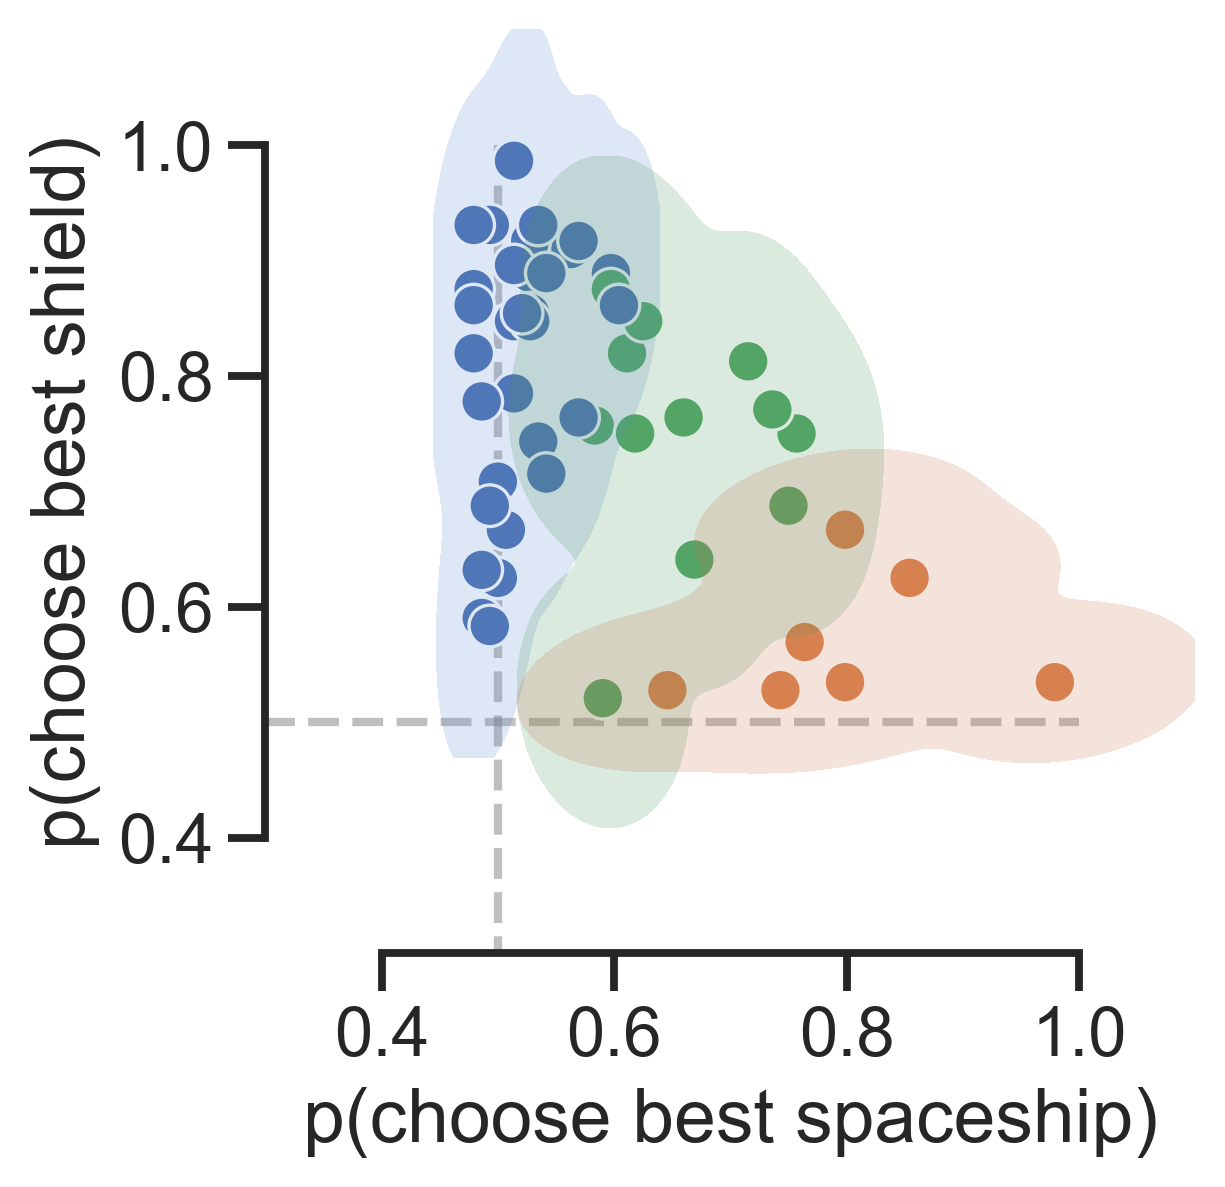

In [ ]:
# same but with scatterplot

import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
exp = 'exp1'
df_ = df[(df.expName==exp) & (df.session==3) & (df.group!='random') & (df.pair.isin([0, 1]))].groupby(['prolificID', 'group2'], as_index=False).mean(numeric_only=True)
# df_ = df_[df_.group!='random']
sns.set(rc={'figure.figsize':(4,4), 'figure.dpi': 300})
sns.set_context("talk")
sns.set_style("ticks")


# # sort by group 
order = ['perceptual', 'combined', 'value']
df_['group2'] = pd.Categorical(df_['group2'], categories=order, ordered=True)


scatter = sns.scatterplot(data=df_, x='opti_ss', y='opti_ff', hue='group2', palette=['C0', 'C2', 'C1', 'C7'], s=100)


# using seaborn, we want a region of interest using the colors of the clusters in scatterplot
sns.kdeplot(data=df_, x='opti_ss', y='opti_ff', alpha=0.2, fill=True, 
            palette=['C0', 'C2', 'C1'], hue='group2', levels=2, bw_adjust=0.6, thresh=0.001) 
# Draw kdeplot for clusters with sufficient points

            

# add a third dimension (opti_ev)
plt.ylim(0.3, 1.1)
plt.xlim(0.3, 1.1)

# add identity line (x=y)
# plt.plot([0.3, 1], [0.3, 1], color='grey', lw=2, zorder=-100, alpha=0.5)

# add 0.5 line v and h
# plt.axhline(0.5, color='grey', lw=2, ls='--', alpha=0.5, zorder=-100)
# plt.axvline(0.5, color='grey', lw=2, ls='--', alpha=0.5 , zorder=-100)

plt.plot([0, 1], [.5, .5], color='grey', lw=2, ls='--', alpha=0.5, zorder=-100)
plt.plot([.5, .5], [0, 1], color='grey', lw=2, ls='--', alpha=0.5, zorder=-100)

plt.xlabel('p(choose best spaceship)')
plt.ylabel('p(choose best shield)')
# put legend outside
# N = len(data)
# plt.title(f'counterfactual+R/2; N={N}')
sns.despine(trim=True)
#no legend
# plt.legend().remove()

#
# use order for legend
handles, labels = plt.gca().get_legend_handles_labels()
labels = ['perceptual', 'value', 'combined']
handles = [handles[order.index(label)] for label in labels]
labels = [f'{label} ({len(df_[df_.group2==label])})' for label in labels]
plt.legend(title='', bbox_to_anchor=(0.125, -.35), labels=labels, handles=handles,
           loc=2, borderaxespad=0.)

# legend order
plt.legend().remove()

In [1]:
# df_fit.to_csv('../data/processed/omega_fit_full.csv', index=False)

import pandas as pd
df_fit = pd.read_csv('../data/processed/omega_fit_full.csv')

In [ ]:

df_fit[(df_fit.exp=='exp1') & (df_fit.group!='random')].groupby('prolificID').last().group.value_counts(normalize=True)

group
perceptual    0.607843
combined      0.254902
value         0.137255
Name: proportion, dtype: float64

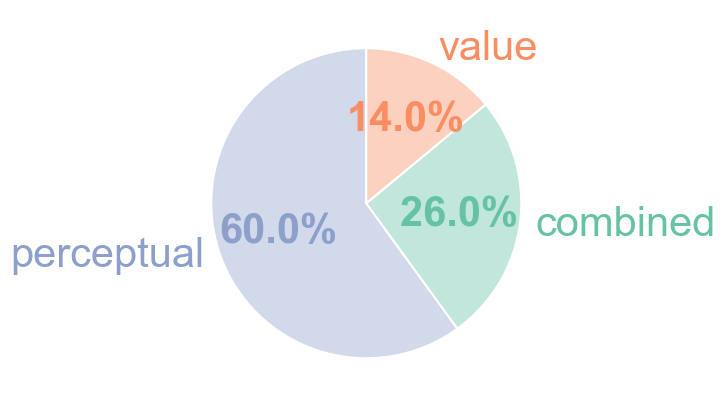

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.set_palette('Set2')
# Data
groups =  ['perceptual', 'combined', 'value']
exp = 'exp1B'
means = df_fit[(df_fit.exp==exp) & (df_fit.group!='random')].groupby('prolificID').last().group.value_counts(normalize=True)
means = means.reindex(groups, fill_value=0)  # Ensures all groups exist in the expected order
# sort means by groups
means = means.loc[groups].values
# Explode Shoes slice
# explode = (0, 0.1, 0)  # Explode each slice slightly

colors = ['C2', 'C0', 'C1']
# colors with alpha = 0.5
colors2 = [(r, g, b, 0.4) for r, g, b in sns.color_palette('Set2')]
# select 0, 2, 7, 1
colors2 = [colors2[i] for i in [2, 0, 1]]

# Create pie chart
wedges, texts, autotexts = plt.pie(means, labels=groups,  colors=colors2, autopct='%1.1f%%', startangle=90)

for i, autotext in enumerate(autotexts):
    autotext.set_color(colors[i])
    autotext.set_fontsize(30)
    autotext.set_fontweight('bold')

for i, text in enumerate(texts):
    text.set_color(colors[i])
    text.set_fontsize(30)



In [ ]:
import pingouin as pg
# compare omega between exp1 and exp1B using t-test
df_fit_ = df_fit[(df_fit.model=='map') & (df_fit.group!='random')]
pg.ttest(
    x=df_fit_[df_fit_.exp=='exp1'].omega,
    y=df_fit_[df_fit_.exp=='exp1B'].omega,
)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,0.222491,98.745874,two-sided,0.824391,"[-0.1, 0.13]",0.044293,0.215,0.055583


In [39]:

from scipy.stats import chi2_contingency
# how to statistically compare the proportion of groups across experiments?
# we can use a chi-squared test
import numpy as np
import scipy.stats as stats
# chi-squared test
# print(stats.chi2_contingency(proportion.groupby(['expName', 'group']).proportion.sum().unstack().T))
import pingouin as pg
# use pingouin to do pairwise wilcoxon tests
#create a df containing each prolificID and the group it belongs to and the expName
# df_ = df.groupby(['prolificID', 'expName'], as_index=False).group2.first()
df_fit = pd.read_csv('../data/processed/omega_fit_full.csv')
df_ = df_fit[df_fit.group!='random']


expected, observed, stats = pg.chi2_independence(data=df_, x='exp', y='group', correction=True)
# pg.pairwise_tests(data=proportion, dv='proportion', between='expName', within='group', padjust='bonf', within_first=False)from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df_['exp'], df_['group'])
chi2, p, dof, ex = chi2_contingency(contingency_table)

n = contingency_table.sum().sum()
r, k = contingency_table.shape
cramers_v = np.sqrt(chi2 / (n * min(r-1, k-1)))
# Print results
print("Chi-squared test statistic:", np.round(chi2, 3))
print('Cramer\'s V:', np.round(cramers_v, 3))
print("p-value:", np.round(p,4))


Chi-squared test statistic: 29.018
Cramer's V: 0.267
p-value: 0.0001


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# now do the same as all the code above but with rank-based analysis, i.e., we compare the proportion of group 'value', 'perceptual', 'combined' and 'random' in each experiment
df2 = df[df.session == 3]
#df2 = df2[df2.group != 'random']

# set group2 

proportion = df2.groupby(['expName', 'group2']).prolificID.nunique().unstack().T
proportion = proportion.div(proportion.sum(axis=0), axis=1)
# make proportion to a df with columns group, expName, and expName
proportion = proportion.reset_index().melt(id_vars='group2', var_name='expName', value_name='proportion')
df_ = df2.groupby(['prolificID', 'expName'], as_index=False).group.first()
sns.set(style='ticks')
sns.set_context('talk')
sns.set_palette('Set2')
# sns.barplot(
#     data=proportion,
#     x='expName',
#     y='proportion',
#     hue='group',
#     hue_order=['perceptual', 'value', 'combined', 'random'],
#     palette=['#1f77b4', '#ff7f0e', '#2ca02c', 'grey'],
# )
# stacked barplot
df_['group'] =  pd.Categorical(df_['group2'], categories=['perceptual', 'value', 'combined', 'random'], ordered=True)
df_['expName'] = pd.Categorical(df_['expName'], categories=['exp1', 'exp2', 'exp3'], ordered=True)
# remove exp3
# df_ = df_[df_.expName != 'exp3']
sns.histplot(
    data=df_,
    x='expName',
    hue='group',
    multiple='fill',
    palette=['C2', 'C1', 'C0'],
    hue_order=['perceptual', 'value', 'combined'],
    shrink=0.7,
    edgecolor='w',
    alpha=0.8,
)
plt.ylabel('proportion')
# reorder the x-axis
# bar at 1 should be at 0, bar at 0 should be at 1, and bar at 2 should be at 2
plt.xticks([0, 1, 2], ['all or none', 'partial rew.', 'partial destroy'])
plt.xlabel('Exp.')
# plt.xlabel('')

import matplotlib.pyplot as plt
plt.ylim(0, 1)
plt.xlim(-0.5, 2.5)
sns.despine(left=True, offset={'left': 50}, trim=True, bottom=True)
# remove ticks but keep labels associated with ticks
plt.tick_params(axis='x', length=0)
plt.tick_params(axis='y', length=0)

# put legend outside
# plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.legend().remove()


KeyError: 'group2'

C:\Users\basil\AppData\Local\Temp\ipykernel_38104\2760503095.py:25: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.violinplot(data=data, x=x, y="beta", palette=palette, split=True, gap=0.3,


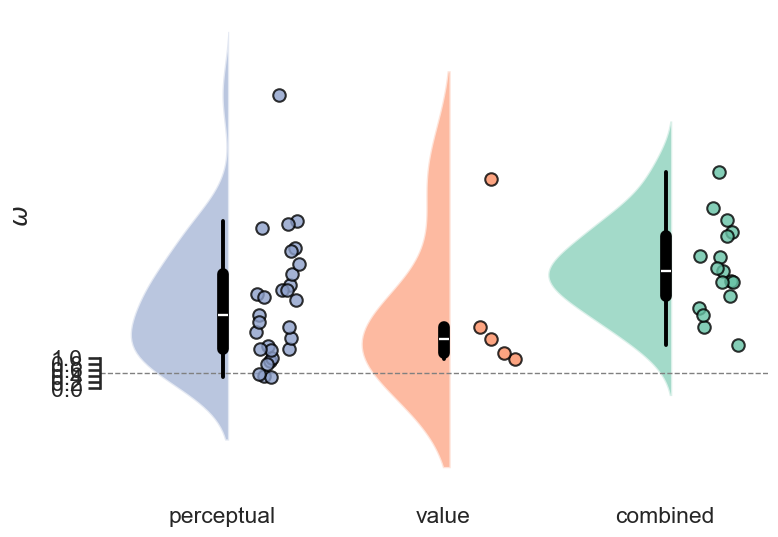

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# --- Prepare plot --- #
sns.set({'figure.figsize': (8, 6)})
sns.set_context('talk')
sns.set_style('ticks')
sns.set_palette('Set2')
palette = ['C2', 'C1', 'C0', 'grey']
group_names = ['perceptual', 'value', 'combined']
order = ['perceptual', 'value', 'combined']

group_positions = {g: i for i, g in enumerate(group_names)}
x = 'group'
data = df_fit[(df_fit.model=='map') & (df_fit.exp=='exp1')].groupby(['group', 'prolificID']).last().reset_index()
data['group'] = pd.Categorical(data['group'], categories=order, ordered=True)
# remove random from data
data = data[data.group != 'random']

df = data.copy()
# --- Violin plots --- #
sns.violinplot(data=data, x=x, y="beta", palette=palette, split=True, gap=0.3,
               hue=True, hue_order=[True, False], alpha=.6, linecolor='w', zorder=0,
                 inner_kws={'color': 'black', 'linewidth': 0.5}, inner='box')
# --- Manually set half violin colors --- #
ax = plt.gca()
plt.xlabel('Group')

for i, collection in enumerate(ax.collections):
    if hasattr(collection, 'get_paths') and len(collection.get_paths()) > 0:
        # This is a violin body
        violin_idx = i # Each violin has 2 collections (left and right halves)
        if violin_idx < len(palette):
            collection.set_facecolor(palette[violin_idx])
            collection.set_alpha(0.6)

# --- Stripplot with controlled jitter --- #
jitter_strength = 0.1
bias_to_right = .5
dot_coords = []  # store jittered (x, y, subject)

for i, group in enumerate(group_names):
    subset = df[df["group"] == group]
    jittered_x = i + np.random.uniform(-jitter_strength, jitter_strength, size=len(subset))
    jittered_x += bias_to_right
    y_vals = subset["beta"].values
    subj_ids = subset["prolificID"].values

    plt.scatter(jittered_x, y_vals, color=palette[i], alpha=0.8, zorder=3, edgecolors='black')

    # Save jittered coordinates and subjects
    for x, y, s in zip(jittered_x, y_vals, subj_ids):
        dot_coords.append({"subject": s, "group": group, "x": x, "y": y})


# --- Aesthetics --- #
bias_x_axis = 0.25
# plt.title("Raincloud Plot with Controlled Jitter & Connections", fontsize=14)
# plt.xticks(range(len(group_names)), [1, 2, 3])
plt.xticks([i + bias_x_axis for i in range(len(group_names))], group_names, rotation=0)

sns.despine(bottom=True)
plt.tick_params(axis='x', which='both', bottom=False, top=False)

# the y axis ticks should only show from 0 to 1
plt.yticks(np.arange(0, 1.1, 0.2))
# add horizontal line at y=0.5
plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, zorder=1)
sns.despine(trim=True, bottom=True)
plt.tight_layout()
plt.legend().remove()
plt.ylabel('$\omega$')

plt.xlabel('')
plt.gca().yaxis.set_label_coords(-0.1, 0.57)
from statannotations.Annotator import Annotator
import itertools

# Create pairs of experiments for annotation
pairs = list(itertools.combinations(order, 2))
# remove random from pairs
pairs = [pair for pair in pairs if 'random' not in pair]
order= ['perceptual', 'value', 'combined']
# annotator = Annotator(ax,  pairs, x='group', y='omega',
#                      data=data, order=order)
# annotator.configure(test='t-test_ind', text_format='star', loc='outside').apply_test()

# #compute effect size for each pair
# import pingouin as pg
# d_ = []
# for (i, j) in pairs:
#     d = pg.compute_effsize(data[data.group == i]['omega'], data[data.group == j]['omega'],
#                      eftype='cohen', paired=False)
#     d_.append(abs(d))

# annotator.annotate_custom_annotations([s[:-1] + f' $d={d:.2f}$' for s, d in zip(annotator.get_annotations_text(), d_)])

Correlation: 0.30160799315294423, p-value: 0.03148579236861044


Text(0.7, 1, 'r=0.30\np-value=0.031')

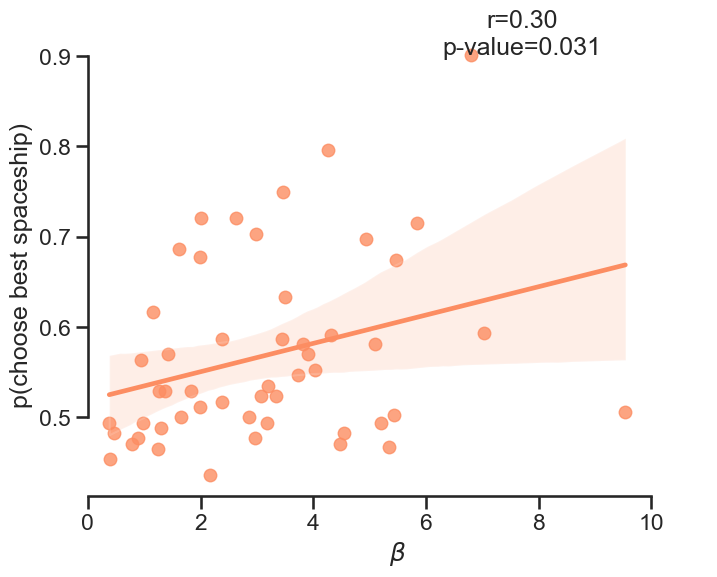

In [ ]:
exp_ = 'exp1'
delta = df_fit[(df_fit.model=='map') & (df_fit.exp==exp_) & (df_fit.group!='random')].groupby(['agent', 'group2', 'model', 'exp']).last().reset_index()

agent = delta.agent.values
group = delta.group2.values
model = delta.model.values
exp = delta.exp

dd2 = pd.DataFrame({
    'agent': agent,
    'expName': exp,
    'group': group,
    'model': model,
    'omega': delta.omega.values,
    'beta': delta.beta.values,
    'll': delta.ll.values,
    'opti_ss': df[df.prolificID.isin(delta.agent.values) & (df.session==3) & (df.expName==exp_)].groupby('prolificID').opti_ss.mean().values,
    'opti_ff': df[df.prolificID.isin(delta.agent.values) & (df.session==3) & (df.expName==exp_)].groupby('prolificID').opti_ff.mean().values
})

sns.regplot(x='beta', y='opti_ss', data=dd2, color='C1')

plt.ylabel('p(choose best spaceship)')
plt.xlabel('$\\beta$')
plt.xlim(0, 11)
# compute correlation
import scipy.stats as stats
sns.despine(trim=True)

corr, pval = stats.pearsonr(dd2['opti_ss'], dd2['beta'])
print(f"Correlation: {corr}, p-value: {pval}")

# put the correlation in the plot
import matplotlib.pyplot as plt

plt.text(0.7, 1, f"r={corr:.2f}\np-value={pval:.3f}", ha='center', va='center', transform=plt.gca().transAxes)

Text(0, 0.5, '$\\omega$')

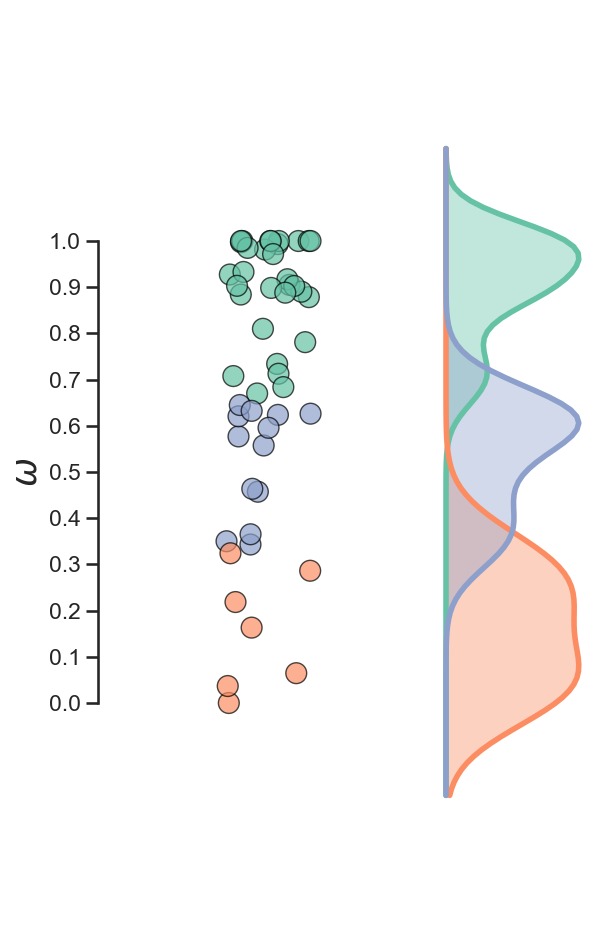

In [ ]:
import scipy.stats as stats
np.random.seed(42)
exp_ = 'exp1'
delta = df_fit[(df_fit.model=='map') & (df_fit.exp==exp_) & (df_fit.group!='random')].groupby(['agent', 'group2', 'model', 'exp']).last().reset_index()

agent = delta.agent.values
group = delta.group2.values
model = delta.model.values
exp = delta.exp

dd2 = pd.DataFrame({
    'agent': agent,
    'expName': exp,
    'group': group,
    'model': model,
    'delta': delta.omega.values,
    'll': delta.ll.values,
})

dd2 = dd2[(dd2.group!='random') & (dd2.expName==exp_) & (dd2.group.isin(['value', 'perceptual', 'combined']))]
groups = dd2.group.unique()
# in groups the order should be ['perceptual', 'value', 'combined']
# Sort groups to ensure consistent order
groups = sorted(groups, key=lambda x: ['perceptual', 'value', 'combined'].index(x))
palette = sns.color_palette('Set2')
palette = [palette[2], palette[1], palette[0]]
sns.set({'figure.figsize': (5, 12), 'figure.dpi': 100})
sns.set_style('ticks')
sns.set_context('talk')

palette = sns.color_palette('Set2')
# Create a figure with enough width

# Set positions for dots and KDE to be closer together
dot_position = 1
kde_start = 0.4

# Draw the stripplot on the left
sns.stripplot(data=dd2, x=np.ones(len(dd2))*dot_position, y='delta', hue='group', 
              hue_order=groups, palette='Set2',
              edgecolor='black', size=15, linewidth=1, alpha=0.7)

plt.ylim(-.5, 1.5)

# Draw vertical KDE on the right with peaks facing right
for i, group_name in enumerate(groups):
    subset = dd2[dd2.group == group_name]
    # Use gaussian_kde for more control over the orientation
    kde = stats.gaussian_kde(subset['delta'].values)
    x_pts = np.linspace(dd2.delta.min()-0.2, dd2.delta.max()+0.2, 100)
    density = kde(x_pts)
    # Scale density for visibility
    max_density = density.max()
    scaled_density = density / max_density * 0.3  # Scale to make it visible but not too wide
    # Plot the KDE curve horizontally
    plt.fill_betweenx(x_pts, kde_start, kde_start + scaled_density, color=palette[i], alpha=0.4)
    plt.plot(kde_start + scaled_density, x_pts, color=palette[i], lw=4)
    # add space between each kde
    # kde_start += 0.1 # Adjust this value to control the spacing between KDEs

# plt.ylim(min(x_pts) - 100, max(x_pts) + 100)  # Add padding to y-limits to show full distribution
# Set x-axis limits to fit the visualization with less empty space
# plt.xlim(0.5, kde_start + 1.0)
plt.xticks([], [])
plt.ylabel('$\\omega$')
# plt.ylim(-1200, 1500)
# now cut the y-axis at 1000
plt.yticks(np.arange(0, 1.1, .1), fontsize=20)
# Add a legend only once
handles, labels = plt.gca().get_legend_handles_labels()
# legend outside the plot
plt.legend(handles[:3], labels[:3], title='behavioral group', bbox_to_anchor=(1, 1), loc='upper left')
plt.legend().remove()
sns.despine(trim=True, bottom=True, offset=80)
plt.xlabel('')
plt.ylabel('$\\omega$', fontdict={'fontsize': 25})
# set y line at 0.5

In [20]:
dd2

,agent,expName,group,model,delta,ll


In [63]:
dd2

,agent,expName,group,model,delta,ll
0,5484d361fdf99b0379939d5b,FullPilot12,combined,map,0.473719,44.699667
1,58c42d725866f200017c5deb,FullPilot12,perceptual,map,0.887613,50.816780
2,5a580fb6eedc320001426cd7,FullPilot12,perceptual,map,0.904431,34.077714
3,5a9353586219a30001d2f2af,FullPilot12,value,map,0.000001,99.298672
4,5a9416ba6475f900019fa690,FullPilot12,perceptual,map,0.999988,42.113725
...,...,...,...,...,...,...
56,66f09b3690fe3df51613a689,FullPilot12,combined,map,0.473994,48.986542
57,66f6c4195f17d26ce8c8018d,FullPilot12,perceptual,map,0.992290,65.428792
58,66f7102d3196ce5e60b2c1bd,FullPilot12,perceptual,map,0.948233,66.476193
59,66fc60b6f59bcb7d6dba7d4f,FullPilot12,perceptual,map,0.999995,84.962641


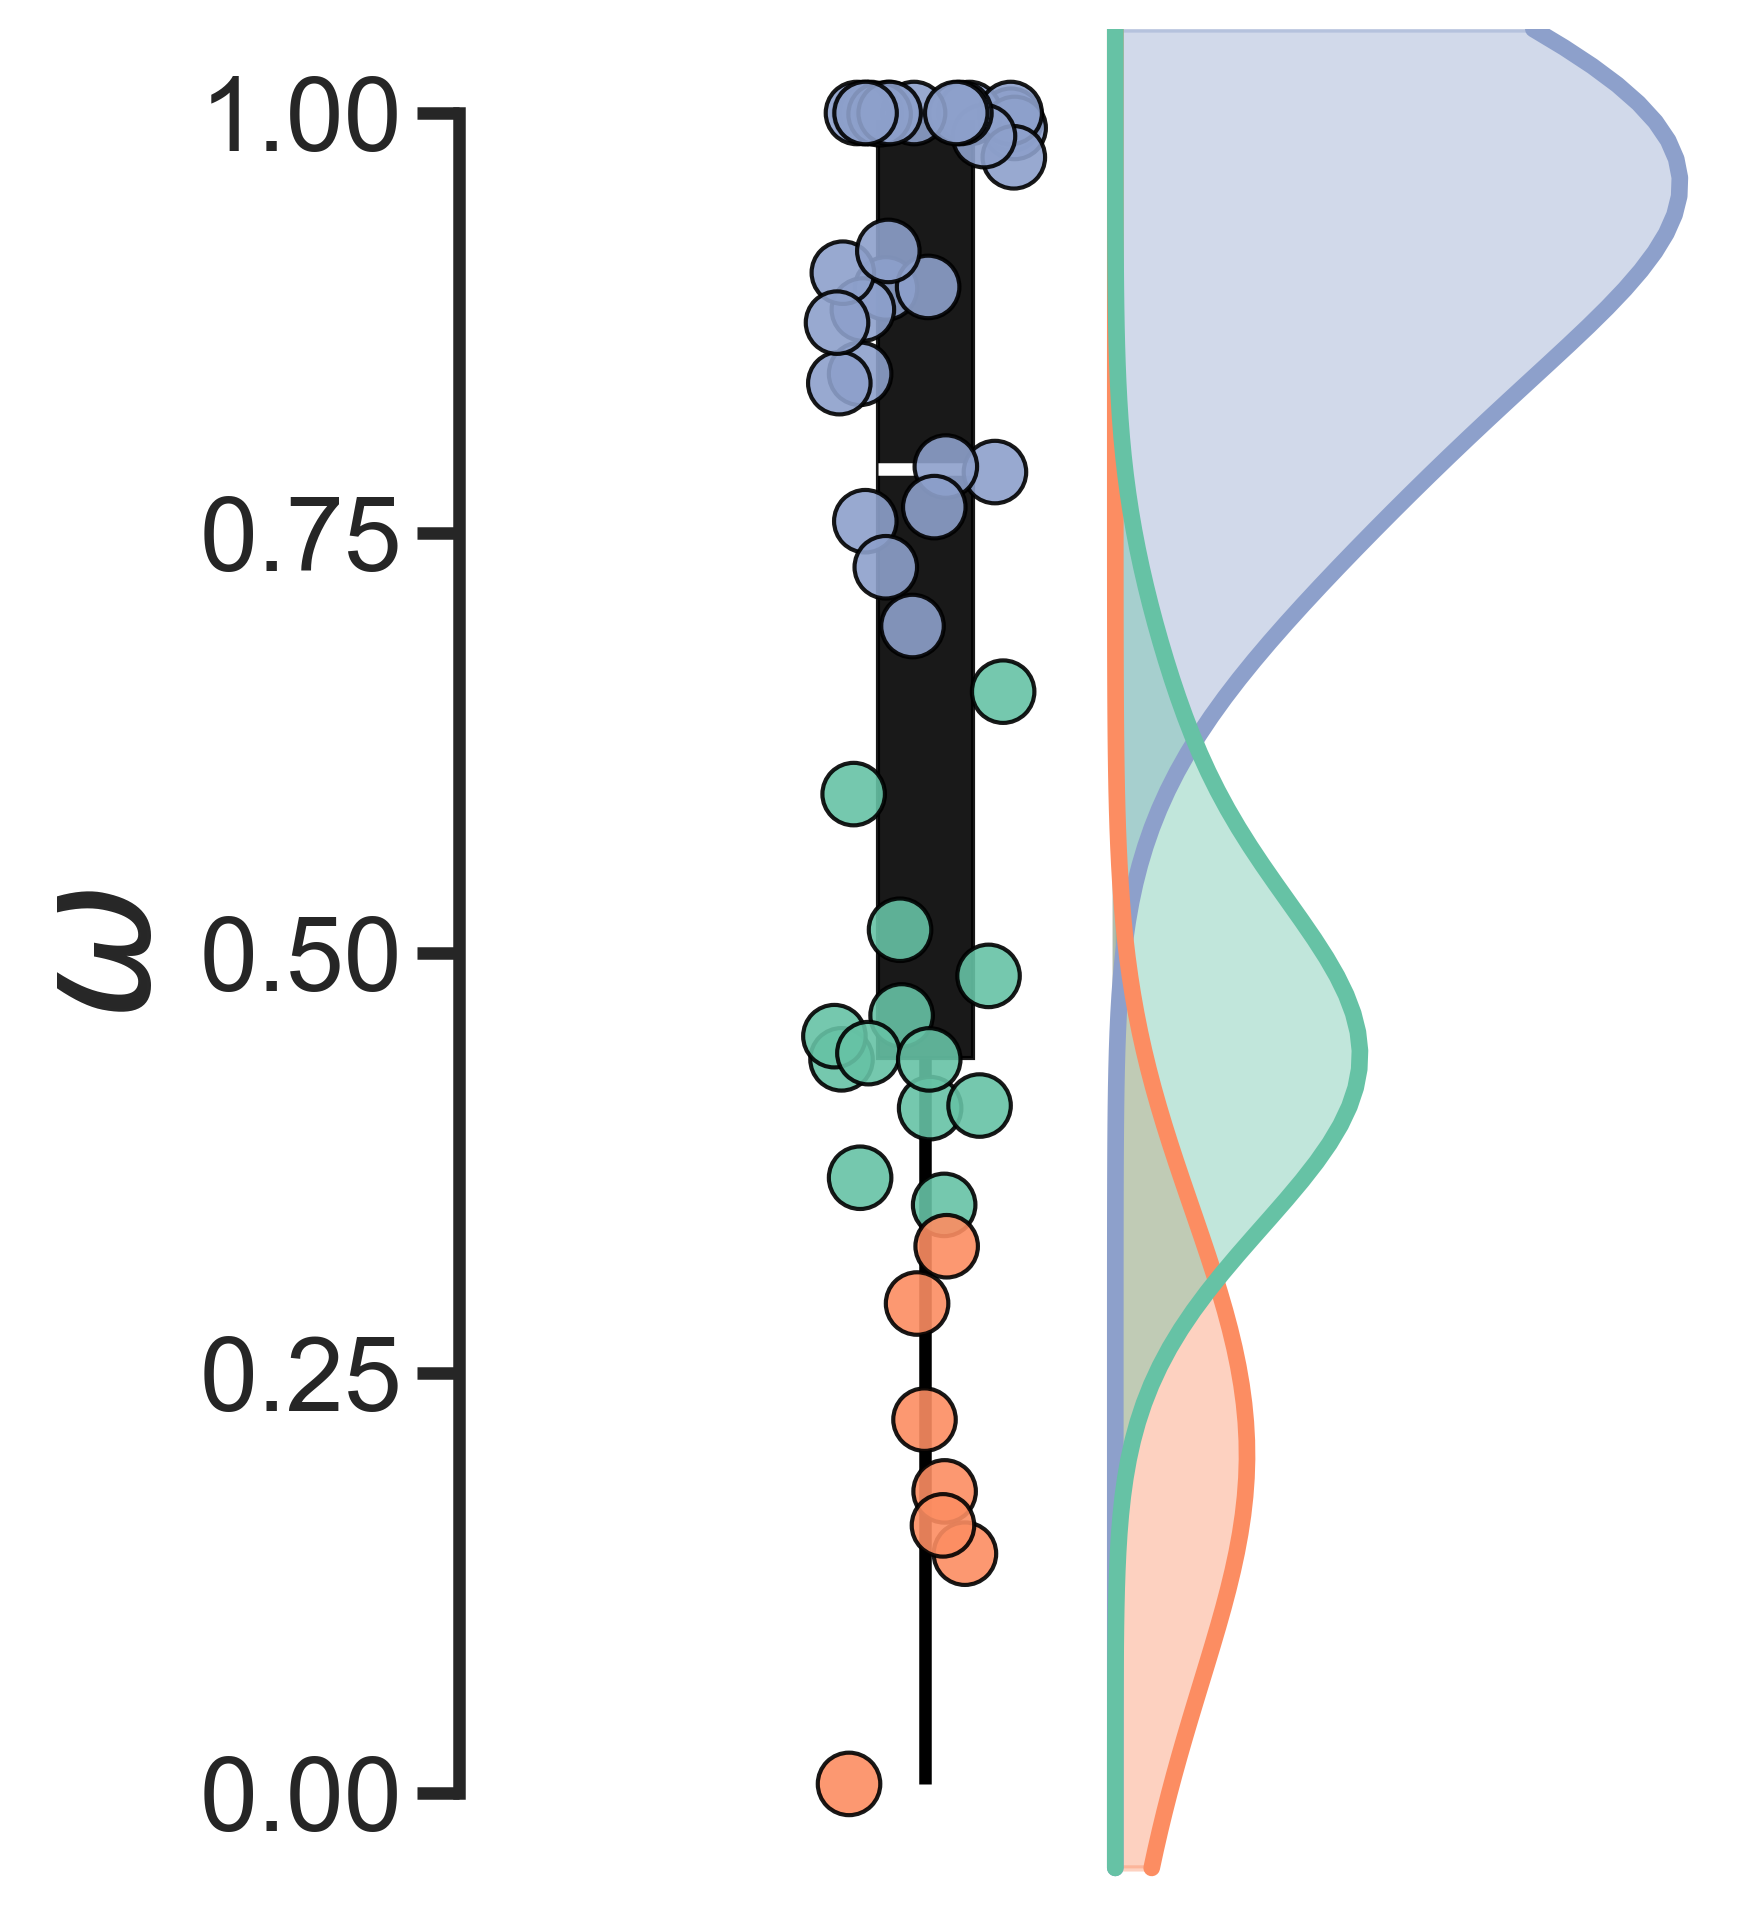

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# I've created a dummy dataframe to make the code runnable.
# You should use your original dataframe.
np.random.seed(42)
exp_ = 'exp1'
# df_fit['group2'] = df_fit.apply(lambda x: df[(df.prolificID == x.agent)]['group'].values[0], axis=1)
delta = df_fit[(df_fit.model=='map') & (df_fit.exp==exp_) & (df_fit.group!='random')].groupby(['agent', 'group', 'model', 'exp']).last().reset_index()

agent = delta.agent.values
group = delta.group.values
model = delta.model.values
exp = delta.exp

dd2 = pd.DataFrame({
    'agent': agent,
    'expName': exp,
    'group': group,
    'model': model,
    'delta': delta.omega.values,
    'll': delta.ll.values,
})

dd2 = dd2[(dd2.expName==exp_) & (dd2.group.isin(['value', 'perceptual', 'combined']))]
groups = dd2.group.unique()
# in groups the order should be ['perceptual', 'value', 'combined']
# Sort groups to ensure consistent order
groups = sorted(groups, key=lambda x: ['perceptual', 'value', 'combined'].index(x))

groups = dd2.group.unique()
groups = sorted(groups, key=lambda x: ['perceptual', 'value', 'combined'].index(x))
palette = sns.color_palette('Set2')
palette = [palette[2], palette[1], palette[0]]
sns.set({'figure.figsize': (5, 8), 'figure.dpi': 100})
sns.set_style('ticks')
sns.set_context('talk')

palette = sns.color_palette('Set2')
palette = [palette[2], palette[1], palette[0]]
dot_position = -.5

kde_start = 0.2

# --- Start of new code ---
# Added the boxplot here

# plot horizontal line, grey dotted, at y=.33 and .66

# plot it manually
plt.figure(figsize=(4, 8), dpi=300)
sns.set_context('talk')

sns.boxplot(y='delta', data=dd2, color='black', width=0.1, x=np.ones(len(dd2))*dot_position,
            boxprops=dict(facecolor='black', zorder=1, alpha=0.9),
            whiskerprops=dict(color='black', zorder=1, linewidth=3),
            capprops=dict(color='black', zorder=1, linewidth=0),
            medianprops=dict(color='white', zorder=2, linewidth=3),
            showfliers=False, # Do not show outlier fliers
            saturation=1,
            ax=plt.gca() # Use the current axes
            )
# --- End of new code ---

# Draw the stripplot on the left
sns.stripplot(data=dd2, x=np.ones(len(dd2))*dot_position, y='delta', hue='group',
              hue_order=groups, palette=palette,
              edgecolor='black', size=15, linewidth=1, alpha=0.9, zorder=2) # zorder > boxplot zorder
# Replace stripplot with swarmplot to arrange dots according to their density
# sns.swarmplot(data=dd2, y='delta', hue='group',
#               hue_order=groups, palette='Set2',
#               edgecolor='black', size=10, linewidth=1, # Reduced size from 15 for a better layout
#               alpha=0.7, zorder=2, legend=False)
plt.ylim(-.05, 1.05)

# --- Start of modified code ---

# Define the points for density evaluation based on the total sample
x_pts = np.linspace(dd2.delta.min() - 0.05, dd2.delta.max() + 0.05, 100)

# Calculate overall KDE for scaling reference
overall_kde = stats.gaussian_kde(dd2['delta'].values, bw_method=1)
overall_density = overall_kde(x_pts)
max_overall_density = overall_density.max()

for i, group_name in enumerate(groups):
    subset = dd2[dd2.group == group_name]
    
    # Calculate KDE for this group
    group_kde = stats.gaussian_kde(subset['delta'].values, bw_method=1)
    group_density = group_kde(x_pts)
    
    # Scale by group size and normalize by overall max for consistent scaling
    scaled_density = (group_density / group_density.max()) * len(subset) / len(dd2) * max_overall_density **0.1
    
    plt.fill_betweenx(x_pts, kde_start, kde_start + scaled_density, color=palette[i], alpha=0.4)
    plt.plot(kde_start + scaled_density, x_pts, color=palette[i], lw=4)

# # 1. First, calculate all densities and find the global maximum
# all_densities = []
# for group_name in groups:
#     subset = dd2[dd2.group == group_name]
#     kde = stats.gaussian_kde(subset['delta'].values, bw_method=1)
#     density = kde(x_pts)
#     all_densities.append(density)

# all_densities = [x**3 for x in all_densities]
# # Find the peak density value across all calculated densities
# global_max_density = np.max(all_densities)

# # 2. Now, plot each KDE, scaling by the global maximum density
# for i, (group_name, density) in enumerate(zip(groups, all_densities)):
#     # Scale density for visibility using the global max
#     scaled_density = density / global_max_density * 0.5  # Scale to make it visible but not too wide
    
#     # Plot the KDE curve horizontally
#     plt.fill_betweenx(x_pts, kde_start, kde_start + scaled_density, color=palette[i], alpha=0.4)
#     plt.plot(kde_start + scaled_density, x_pts, color=palette[i], lw=4)

# --- End of modified code ---

plt.xticks([], [])
plt.ylabel('$\\omega$')
plt.yticks(np.arange(0, 1.1, .25), fontsize=40)
handles, labels = plt.gca().get_legend_handles_labels()
# compute the N for each group
N = [len(dd2[dd2.group==g]) for g in groups]
labels = [f'{label} ({n})' for label, n in zip(labels, N)]
# legend outside the plot
# plt.legend(handles[:3], labels[:3], title='behavioral group', bbox_to_anchor=(1, 1), loc='upper left')
plt.legend(title='',  labels=labels, handles=handles[:3], bbox_to_anchor=(1.7, .6), fontsize=20, 
              borderaxespad=0.)
plt.legend().remove()

sns.despine(trim=True, bottom=True, offset=80)
plt.xlabel('')
plt.ylabel('$\\omega$', fontdict={'fontsize': 40})
# change y tick label size
plt.yticks(fontsize=25)

#change axis width y  axis
plt.gca().spines['left'].set_linewidth(3)
# tick width
plt.gca().tick_params(width=3, length=10)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0, 0.5, '$\\omega$')

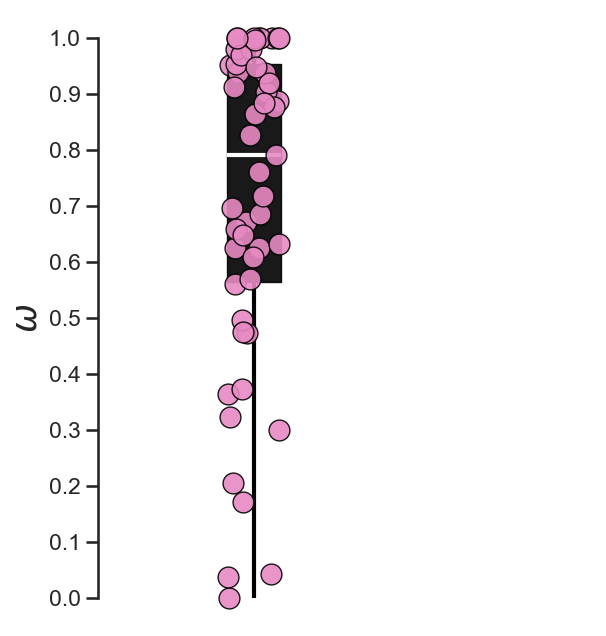

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# I've created a dummy dataframe to make the code runnable.
# You should use your original dataframe.
np.random.seed(42)
exp_ = 'exp1'
df_fit['group2'] = df_fit.apply(lambda x: df[(df.prolificID == x.agent)]['group'].values[0], axis=1)
delta = df_fit[(df_fit.model=='map') & (df_fit.exp==exp_) & (df_fit.group2!='random')].groupby(['agent', 'group2', 'model', 'exp']).last().reset_index()

agent = delta.agent.values
group = delta.group2.values
model = delta.model.values
exp = delta.exp

dd2 = pd.DataFrame({
    'agent': agent,
    'expName': exp,
    'group': group,
    'model': model,
    'delta': delta.omega.values,
    'll': delta.ll.values,
})

dd2 = dd2[(dd2.group!='random') & (dd2.expName==exp_) & (dd2.group.isin(['value', 'perceptual', 'combined']))]
groups = dd2.group.unique()
# in groups the order should be ['perceptual', 'value', 'combined']
# Sort groups to ensure consistent order
groups = sorted(groups, key=lambda x: ['perceptual', 'value', 'combined'].index(x))

groups = dd2.group.unique()
groups = sorted(groups, key=lambda x: ['perceptual', 'value', 'combined'].index(x))
palette = sns.color_palette('Set2')
palette = [palette[2], palette[1], palette[0]]
sns.set({'figure.figsize': (5, 8), 'figure.dpi': 100})
sns.set_style('ticks')
sns.set_context('talk')

palette = sns.color_palette('Set2')
# palette = [palette[2], palette[1], palette[0]]
dot_position = -.5

kde_start = 0.2

# --- Start of new code ---
# Added the boxplot here

# plot horizontal line, grey dotted, at y=.33 and .66

# plot it manually


sns.boxplot(y='delta', data=dd2, color='black', width=0.2, x=np.ones(len(dd2))*dot_position,
            boxprops=dict(facecolor='black', zorder=1, alpha=0.9),
            whiskerprops=dict(color='black', zorder=1, linewidth=3),
            capprops=dict(color='black', zorder=1, linewidth=0),
            medianprops=dict(color='white', zorder=2, linewidth=3),
            showfliers=False, # Do not show outlier fliers
            saturation=1,
            ax=plt.gca() # Use the current axes
            )
# --- End of new code ---

# Draw the stripplot on the left
sns.stripplot(data=dd2, x=np.ones(len(dd2))*dot_position, y='delta', color=palette[3],
              hue_order=groups, 
              edgecolor='black', size=15, linewidth=1, alpha=0.9, zorder=2) # zorder > boxplot zorder
# Replace stripplot with swarmplot to arrange dots according to their density
# sns.swarmplot(data=dd2, y='delta', hue='group',
#               hue_order=groups, palette='Set2',
#               edgecolor='black', size=10, linewidth=1, # Reduced size from 15 for a better layout
#               alpha=0.7, zorder=2, legend=False)
plt.ylim(-.05, 1.05)

# --- Start of modified code ---

# Define the points for density evaluation based on the total sample
x_pts = np.linspace(dd2.delta.min() - 0.05, dd2.delta.max() + 0.05, 100)

# Calculate overall KDE for scaling reference
overall_kde = stats.gaussian_kde(dd2['delta'].values, bw_method=1)
overall_density = overall_kde(x_pts)
max_overall_density = overall_density.max()

subset = dd2[dd2.group.isin([groups])]

# Calculate KDE for this group
group_kde = stats.gaussian_kde(dd2.delta.values, bw_method=1)
group_density = group_kde(x_pts)

# Scale by group size and normalize by overall max for consistent scaling
scaled_density = (group_density / group_density.max()) * len(dd2) / len(dd2) * max_overall_density *

plt.fill_betweenx(x_pts, kde_start, kde_start + scaled_density, color=palette[3], alpha=0)
plt.plot(kde_start + scaled_density, x_pts, color=palette[3], lw=4, alpha=0)


plt.xticks([], [])
plt.ylabel('$\\omega$')
plt.yticks(np.arange(0, 1.1, .1), fontsize=20)
handles, labels = plt.gca().get_legend_handles_labels()
# compute the N for each group
N = [len(dd2[dd2.group==g]) for g in groups]
labels = [f'{label} ({n})' for label, n in zip(labels, N)]
# legend outside the plot
# plt.legend(handles[:3], labels[:3], title='behavioral group', bbox_to_anchor=(1, 1), loc='upper left')
plt.legend(title='',  labels=labels, handles=handles[:3], bbox_to_anchor=(0.5, -0.05), 
              borderaxespad=0.)
plt.legend().remove()

sns.despine(trim=True, bottom=True, offset=80)
plt.xlabel('')
plt.ylabel('$\\omega$', fontdict={'fontsize': 25})


In [30]:
dd2.group

0       combined
1     perceptual
2     perceptual
3          value
4     perceptual
         ...    
56      combined
57    perceptual
58    perceptual
59    perceptual
60    perceptual
Name: group, Length: 61, dtype: object

Text(0, 0.5, '$\\omega$')

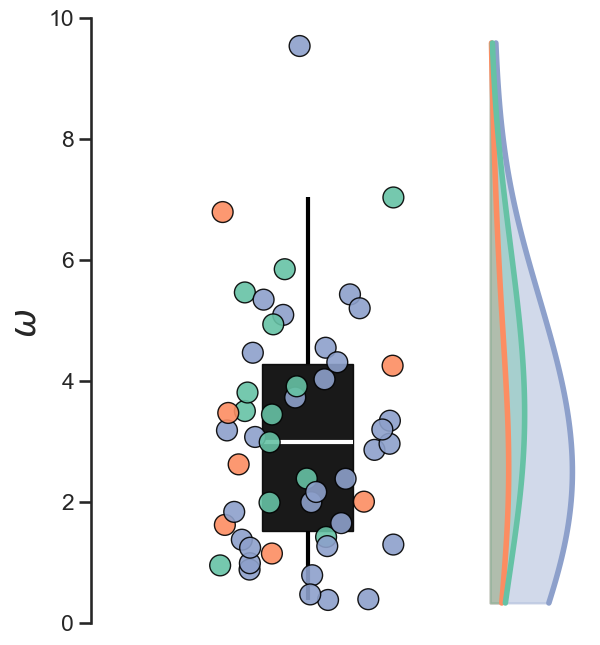

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# I've created a dummy dataframe to make the code runnable.
# You should use your original dataframe.
np.random.seed(42)
exp_ = 'exp1'
delta = df_fit[(df_fit.model=='map') & (df_fit.exp==exp_) & (df_fit.group!='random')]\
    .groupby(['agent', 'group2', 'model', 'exp']).last().reset_index()

agent = delta.agent.values
group = delta.group2.values
model = delta.model.values
exp = delta.exp

dd2 = pd.DataFrame({
    'agent': agent,
    'expName': exp,
    'group': group,
    'model': model,
    'delta': delta.beta.values,
    'll': delta.ll.values,
})

dd2 = dd2[(dd2.group!='random') & (dd2.expName==exp_) & (dd2.group.isin(['value', 'perceptual', 'combined']))]
groups = dd2.group.unique()
# in groups the order should be ['perceptual', 'value', 'combined']
# Sort groups to ensure consistent order
groups = sorted(groups, key=lambda x: ['perceptual', 'value', 'combined'].index(x))

exp_ = 'exp2'
groups = dd2.group.unique()
groups = sorted(groups, key=lambda x: ['perceptual', 'value', 'combined'].index(x))
palette = sns.color_palette('Set2')
palette = [palette[2], palette[1], palette[0]]
sns.set({'figure.figsize': (5, 8), 'figure.dpi': 100})
sns.set_style('ticks')
sns.set_context('talk')

palette = sns.color_palette('Set2')
palette = [palette[2], palette[1], palette[0]]
dot_position = -.5

kde_start = 0.2

# --- Start of new code ---
# Added the boxplot here

# plot horizontal line, grey dotted, at y=.33 and .66

# plot it manually


sns.boxplot(y='delta', data=dd2, color='black', width=0.1, x=np.ones(len(dd2))*dot_position,
            boxprops=dict(facecolor='black', zorder=1, alpha=0.9),
            whiskerprops=dict(color='black', zorder=1, linewidth=3),
            capprops=dict(color='black', zorder=1, linewidth=0),
            medianprops=dict(color='white', zorder=2, linewidth=3),
            showfliers=False, # Do not show outlier fliers
            saturation=1,
            ax=plt.gca() # Use the current axes
            )
# --- End of new code ---

# Draw the stripplot on the left
sns.stripplot(data=dd2, x=np.ones(len(dd2))*dot_position, y='delta', hue='group',
              hue_order=groups, palette=palette,
              edgecolor='black', size=15, linewidth=1, alpha=0.9, zorder=2) # zorder > boxplot zorder
# Replace stripplot with swarmplot to arrange dots according to their density
# sns.swarmplot(data=dd2, y='delta', hue='group',
#               hue_order=groups, palette='Set2',
#               edgecolor='black', size=10, linewidth=1, # Reduced size from 15 for a better layout
#               alpha=0.7, zorder=2, legend=False)
# plt.ylim(-.05, 1.05)

# --- Start of modified code ---

# Define the points for density evaluation based on the total sample
x_pts = np.linspace(dd2.delta.min() - 0.05, dd2.delta.max() + 0.05, 100)

# Calculate overall KDE for scaling reference
overall_kde = stats.gaussian_kde(dd2['delta'].values, bw_method=1)
overall_density = overall_kde(x_pts)
max_overall_density = overall_density.max()

for i, group_name in enumerate(groups):
    subset = dd2[dd2.group == group_name]
    
    # Calculate KDE for this group
    group_kde = stats.gaussian_kde(subset['delta'].values, bw_method=1)
    group_density = group_kde(x_pts)
    
    # Scale by group size and normalize by overall max for consistent scaling
    scaled_density = (group_density / group_density.max()) * len(subset) / len(dd2) * max_overall_density
    
    plt.fill_betweenx(x_pts, kde_start, kde_start + scaled_density, color=palette[i], alpha=0.4)
    plt.plot(kde_start + scaled_density, x_pts, color=palette[i], lw=4)

# # 1. First, calculate all densities and find the global maximum
# all_densities = []
# for group_name in groups:
#     subset = dd2[dd2.group == group_name]
#     kde = stats.gaussian_kde(subset['delta'].values, bw_method=1)
#     density = kde(x_pts)
#     all_densities.append(density)

# all_densities = [x**3 for x in all_densities]
# # Find the peak density value across all calculated densities
# global_max_density = np.max(all_densities)

# # 2. Now, plot each KDE, scaling by the global maximum density
# for i, (group_name, density) in enumerate(zip(groups, all_densities)):
#     # Scale density for visibility using the global max
#     scaled_density = density / global_max_density * 0.5  # Scale to make it visible but not too wide
    
#     # Plot the KDE curve horizontally
#     plt.fill_betweenx(x_pts, kde_start, kde_start + scaled_density, color=palette[i], alpha=0.4)
#     plt.plot(kde_start + scaled_density, x_pts, color=palette[i], lw=4)

# --- End of modified code ---

plt.xticks([], [])
plt.ylabel('$\\omega$')
# plt.yticks(np.arange(0, 1.1, .1), fontsize=20)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:3], labels[:3], title='behavioral group', bbox_to_anchor=(1, 1), loc='upper left')
plt.legend().remove()
sns.despine(trim=True, bottom=True, offset=80)
plt.xlabel('')
plt.ylabel('$\\omega$', fontdict={'fontsize': 25})


Text(0, 0.5, '$\\omega$')

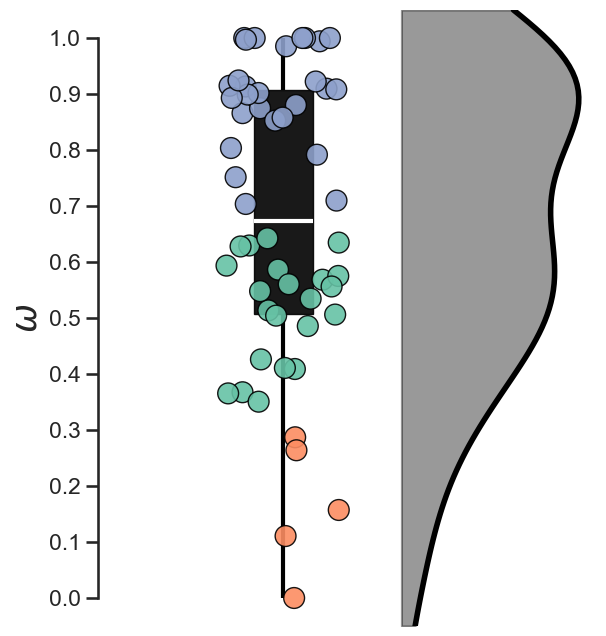

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# I've created a dummy dataframe to make the code runnable.
# You should use your original dataframe.
np.random.seed(42)
exp_ = 'exp3'
delta = df_fit[(df_fit.model=='map') & (df_fit.exp==exp_) & (df_fit.group!='random')].groupby(['agent', 'group2', 'model', 'exp']).last().reset_index()

agent = delta.agent.values
group = delta.group2.values
model = delta.model.values
exp = delta.exp

dd2 = pd.DataFrame({
    'agent': agent,
    'expName': exp,
    'group': group,
    'model': model,
    'delta': delta.omega.values,
    'll': delta.ll.values,
})

dd2 = dd2[(dd2.group!='random') & (dd2.expName==exp_) & (dd2.group.isin(['value', 'perceptual', 'combined']))]
groups = dd2.group.unique()
# in groups the order should be ['perceptual', 'value', 'combined']
# Sort groups to ensure consistent order
groups = sorted(groups, key=lambda x: ['perceptual', 'value', 'combined'].index(x))

groups = dd2.group.unique()
groups = sorted(groups, key=lambda x: ['perceptual', 'value', 'combined'].index(x))
palette = sns.color_palette('Set2')
palette = [palette[2], palette[1], palette[0]]
sns.set({'figure.figsize': (5, 8), 'figure.dpi': 100})
sns.set_style('ticks')
sns.set_context('talk')


sns.set_palette('Set2')
palette = ['C2', 'C1', 'C0']
dot_position = -.5

kde_start = 0.2

# --- Start of new code ---
# Added the boxplot here

# plot horizontal line, grey dotted, at y=.33 and .66

# plot it manually


sns.boxplot(y='delta', data=dd2, color='black', width=0.1, x=np.ones(len(dd2))*dot_position,
            boxprops=dict(facecolor='black', zorder=1, alpha=0.9),
            whiskerprops=dict(color='black', zorder=1, linewidth=3),
            capprops=dict(color='black', zorder=1, linewidth=0),
            medianprops=dict(color='white', zorder=2, linewidth=3),
            showfliers=False, # Do not show outlier fliers
            saturation=1,
            ax=plt.gca() # Use the current axes
            )
# --- End of new code ---

# Draw the stripplot on the left
sns.stripplot(data=dd2, x=np.ones(len(dd2))*dot_position, y='delta', hue='group',
              hue_order=groups, palette=palette,
              edgecolor='black', size=15, linewidth=1, alpha=0.9, zorder=2) # zorder > boxplot zorder
# Replace stripplot with swarmplot to arrange dots according to their density
# sns.swarmplot(data=dd2, y='delta', hue='group',
#               hue_order=groups, palette='Set2',
#               edgecolor='black', size=10, linewidth=1, # Reduced size from 15 for a better layout
#               alpha=0.7, zorder=2, legend=False)
plt.ylim(-.05, 1.05)

# --- Start of modified code ---

# Define the points for density evaluation based on the total sample
x_pts = np.linspace(dd2.delta.min() - 0.05, dd2.delta.max() + 0.05, 100)

# Single KDE for all data combined
x_pts = np.linspace(dd2.delta.min() - 0.05, dd2.delta.max() + 0.05, 100)

# Calculate KDE for the entire dataset
kde = stats.gaussian_kde(dd2['delta'].values, bw_method=0.5)
density = kde(x_pts)

# Scale density for visibility
scaled_density = density / density.max() * 0.3

# Plot the single KDE curve horizontally
plt.fill_betweenx(x_pts, kde_start, kde_start + scaled_density, color='black', alpha=0.4)
plt.plot(kde_start + scaled_density, x_pts, color='black', lw=4)

# --- End of modified code ---

plt.xticks([], [])
plt.ylabel('$\\omega$')
plt.yticks(np.arange(0, 1.1, .1), fontsize=20)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:3], labels[:3], title='behavioral group', bbox_to_anchor=(1, 1), loc='upper left')
plt.legend().remove()
sns.despine(trim=True, bottom=True, offset=80)
plt.xlabel('')
plt.ylabel('$\\omega$', fontdict={'fontsize': 25})


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generate the same sample data
np.random.seed(42)
data = np.concatenate([
    np.random.normal(loc=2, scale=1.5, size=150),
    np.random.normal(loc=8, scale=1.0, size=150)
])
df = pd.DataFrame({'score': data})

# 2. Set up the plot aesthetics
sns.set(style="whitegrid", font_scale=1.2)
fig, ax = plt.subplots(figsize=(6, 8))

# --- PLOTTING LOGIC ---
# We will plot three components:
# - Boxplot: Centered at x=0.
# - Swarmplot: Shifted to the left (e.g., centered at x=-0.25).
# - Half-Violin Plot: Shifted to the right (e.g., starting at x=0.25).

# 3. Plot the boxplot (the summary) at the center
sns.boxplot(
    y='score',
    data=df,
    width=0.25,
    showfliers=False,
    boxprops={'facecolor': 'lightblue', 'edgecolor': 'black', 'zorder': 10},
    medianprops={'color': 'black', 'zorder': 11},
    whiskerprops={'color': 'black', 'zorder': 10},
    capprops={'color': '

SyntaxError: EOL while scanning string literal (2554866286.py, line 33)

In [ ]:
# get omega for exp1
df_fit['group2'] = df_fit.apply(lambda x: df[(df.prolificID == x.agent)]['group'].values[0], axis=1)

avg = df_fit[(df_fit.exp=='exp1') & (df_fit.model=='map') & (df_fit.group2!='random')]\
# sort by prolificID
avg = avg.sort_values('prolificID')
omega = avg.omega.values
group = avg.group.values

# get opti_ss for exp1
opti_ss = df[(df.expName=='exp1') & (df.session==3) & (df.pair.isin([0, 1])) & (df.group!='random')].groupby(['prolificID'])\
    .mean(numeric_only=True).sort_values('prolificID').reset_index().opti_ss.values
opti_ff = df[(df.expName=='exp1') & (df.session==3) & (df.pair.isin([0, 1])) & (df.group!='random')].groupby(['prolificID'])\
    .mean(numeric_only=True).sort_values('prolificID').reset_index().opti_ff.values


# create a dataframe with omega and opti_ss
df_omega_opti = pd.DataFrame({
    'omega': omega,
    'opti_ff': opti_ff,
    'opti_ss': opti_ss,
    'group2': group
})

# change color of lmplot
colors = sns.color_palette("Set2")
sns.set({'figure.figsize': (5, 5), 'figure.dpi': 150})
sns.set_style('ticks')
sns.set_context('talk')
sns.set_palette('Set2')
# sns.set_palette([colors[1]])
sns.scatterplot(x='omega', y='opti_ss', data=df_omega_opti, hue='group2', palette=['C0', 'C2', 'C1'], s=100, edgecolor='black', linewidth=1, alpha=0.9)
plt.xlim(-0.1, 1.1)
plt.ylim(.4, 1)

# step is 0.2
plt.xticks(np.arange(0, 1.1, 0.2), fontsize=20)
plt.yticks(np.arange(0.4, 1.1, 0.1), fontsize=20)

# add the regression black line in the background
sns.regplot(x='omega', y='opti_ss', data=df_omega_opti, scatter=False, color='black', line_kws={'linewidth':2, 'alpha':0.7})
# pearson corr
import scipy.stats as stats

r, p = stats.spearmanr(df_omega_opti.omega, df_omega_opti.opti_ss)

plt.text(0.04, 0.9, f'r={r:.2f}, p={p:.3f}')

plt.xlabel('$\\omega$')
plt.ylabel('p(choose best spaceship)') 

sns.despine(trim=True,)
plt.legend().remove()

NameError: name 'df_fit' is not defined

C:\Users\basil\AppData\Local\Temp\ipykernel_57288\3660072341.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group', y='ll', data=df_fit_, capprops=dict(visible=False),  # This removes the caps


Plotting perceptual with 31 points
Plotting value with 7 points
Plotting combined with 13 points
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

perceptual vs. combined: t-test independent samples, P_val:9.724e-01 t=3.484e-02
combined vs. value: t-test independent samples, P_val:9.834e-01 t=2.114e-02
perceptual vs. value: t-test independent samples, P_val:9.629e-01 t=4.688e-02


(<Axes: ylabel='log likelihood (LL)'>,
  <statannotations.Annotation.Annotation at 0x2a0b8bd1a60>])

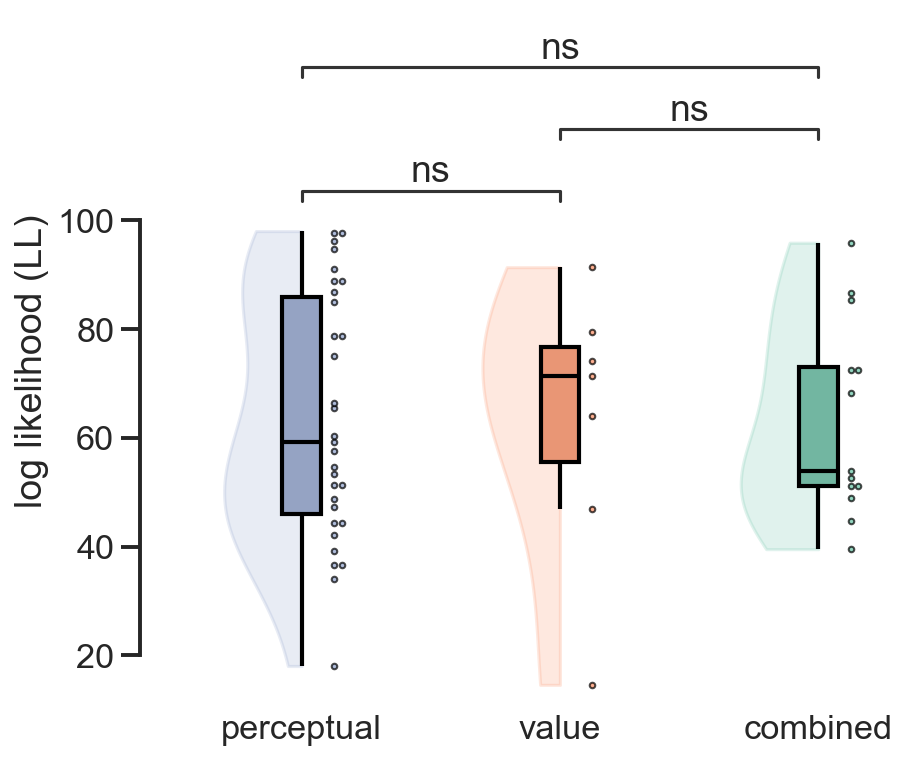

In [ ]:
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt


def violin_scatter_with_binning(x_pos, y_values, width=0.3, n_bins=20, dot_spacing=0.02, y_threshold=None):
    """
    Arrange scatter points in a violin/KDE shape with y-value binning.
    Points with similar y-values are aligned to the same horizontal line.
    
    Parameters:
    -----------
    x_pos : float
        The x-position (left edge) for this group
    y_values : array-like
        The y-values to plot
    width : float
        Maximum width of the violin shape (not used, kept for compatibility)
    n_bins : int
        Number of bins for density estimation
    dot_spacing : float
        Fixed horizontal spacing between dots
    y_threshold : float, optional
        Threshold for grouping y-values together. If None, computed from data.
        Points within this distance will be aligned.
        
    Returns:
    --------
    x_coords, y_coords : arrays
        Coordinates for plotting
    """
    y_values = np.array(y_values)
    
    # If threshold not provided, compute from data (e.g., 5% of range)
    if y_threshold is None:
        y_range_data = y_values.max() - y_values.min()
        y_threshold = y_range_data * 0.05  # 5% of data range
        print('Using y_threshold:', y_threshold)
    
    # Sort y-values for grouping
    sorted_indices = np.argsort(y_values)
    sorted_y = y_values[sorted_indices]
    
    # Group similar y-values together
    y_groups = []
    current_group = [sorted_y[0]]
    
    for i in range(1, len(sorted_y)):
        if (sorted_y[i] - current_group[-1]) <= y_threshold:
            current_group.append(sorted_y[i])
        else:
            y_groups.append(current_group)
            current_group = [sorted_y[i]]
    y_groups.append(current_group)
    
    # Estimate density using KDE
    kde = gaussian_kde(y_values, bw_method='scott')
    
    # Create bins for density
    y_range = np.linspace(y_values.min(), y_values.max(), n_bins)
    
    x_coords = []
    y_coords = []
    
    for group in y_groups:
        # Use mean y-value for this group
        group_y = np.mean(group)
        n_points = len(group)
        
        # Get density at group center
        density = kde(group_y)[0]
        
        # Calculate number of dots to show based on density
        max_density = kde(y_range).max()
        n_dots_to_show = int(np.ceil(n_points * density / max_density))
        n_dots_to_show = min(n_dots_to_show, n_points)
        
        # FIXED EQUAL SPACING: each dot moves by exactly dot_spacing
        x_offsets = [i * dot_spacing for i in range(n_dots_to_show)]
            
        x_coords.extend([x_pos + offset for offset in x_offsets])
        y_coords.extend([group_y] * n_dots_to_show)  # All aligned to same y
    
    return np.array(x_coords), np.array(y_coords)


# Example usage
plt.figure(figsize=(6,6))
sns.set_context('talk')


df_fit_ = df_fit[(df_fit.model=='map') & (df_fit.exp=='exp1') & (df_fit.group2!='random')]
box_width = 0.15

order = ['perceptual', 'value', 'combined']
# Create boxplot
sns.boxplot(x='group', y='ll', data=df_fit_, capprops=dict(visible=False),  # This removes the caps
            linecolor='black', fliersize=0, width=box_width, linewidth=2,  palette=['C2', 'C1', 'C0'],
            order=order, zorder=1)
plt.ylabel('log likelihood (LL)')
# Add half violin on the left and violin-shaped scatter on the right
colors = ['C2', 'C1', 'C0']
new_df = df_fit_[df_fit_.group.isin(order)].copy()
violin_width = 0.3


for i, (type_val, color) in enumerate(zip(order, colors)):
    y_vals = new_df[new_df.group == type_val].ll.values
    print(f'Plotting {type_val} with {len(y_vals)} points')

    # Create half violin on the left side
    kde = gaussian_kde(y_vals, bw_method='scott')
    y_density = np.linspace(y_vals.min(), y_vals.max(), 100)
    density = kde(y_density)
    
    # Normalize density to violin_width
    density_normalized = density / density.max() * violin_width
    
    # Plot left half violin only (negative x direction from center)
    plt.fill_betweenx(y_density, i - density_normalized, i, 
                      color=color, alpha=0.2, zorder=0)
    
    # Add violin-shaped scatter starting from right edge of boxplot
    x_coords, y_coords = violin_scatter_with_binning(i + box_width/2 + 0.05, y_vals, 
                                        width=1, n_bins=40, dot_spacing=0.03, y_threshold=1)
    
    plt.scatter(x_coords, y_coords, s=7, color=color, 
                edgecolor='black', linewidth=1, alpha=0.7, zorder=3)

plt.tick_params(axis='x', length=0)
# plt.ylim(-.1, 1.1)
plt.xlabel('')
# plt.ylabel('average correct choice per participant')
# plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)
sns.despine(trim=True, bottom=True, offset=25)


# stats annontations
pairs = list(itertools.combinations(order, 2))
from statannotations.Annotator import Annotator
annotator = Annotator(plt.gca(), pairs, data=new_df, x='group', y='ll')
annotator.configure(test='t-test_ind', text_format='star', loc='inside', verbose=2)
annotator.apply_and_annotate()

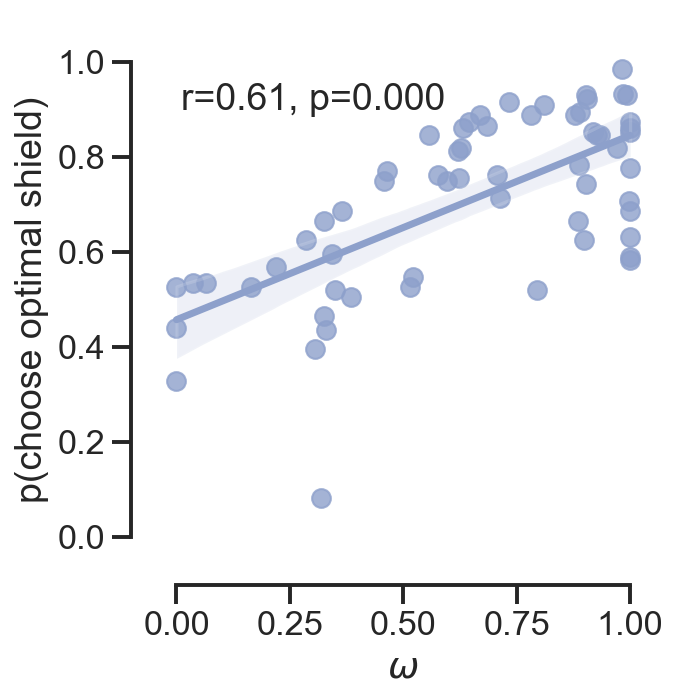

In [ ]:
# get omega for exp1
avg = df_fit[(df_fit.exp=='exp1') & (df_fit.model=='map')]
# sort by prolificID
avg = avg.sort_values('prolificID')
omega = avg.omega.values

# get opti_ss for exp1
opti_ss = df[(df.expName=='exp1') & (df.session==3) & (df.pair.isin([0, 1]))].groupby(['prolificID'])\
    .mean(numeric_only=True).sort_values('prolificID').reset_index().opti_ff.values


# create a dataframe with omega and opti_ss
df_omega_opti = pd.DataFrame({
    'omega': omega,
    'opti_ff': opti_ss
})

# change color of lmplot
colors = sns.color_palette("Set2")
sns.set({'figure.figsize': (5, 6), 'figure.dpi': 150})
sns.set_style('ticks')
sns.set_context('talk')
sns.set_palette([colors[2]])
sns.lmplot(x='omega', y='opti_ff', data=df_omega_opti)

plt.ylim(-0.1,1.1)
plt.xlim(-0.1, 1.1)

# pearson corr
import scipy.stats as stats

r, p = stats.spearmanr(df_omega_opti.omega, df_omega_opti.opti_ff)

plt.text(0.01, 0.9, f'r={r:.2f}, p={p:.3f}')

plt.xlabel('$\\omega$')
plt.ylabel('p(choose optimal shield)') 


sns.despine(trim=True)

Text(0.5, 0.2, 'r=0.03, p=0.86')

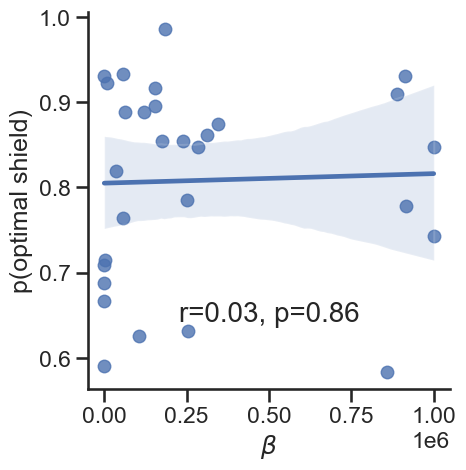

In [ ]:
# plot correlation of opti_ff and beta

sns.lmplot(data=df_fit3[(df_fit3.group=='perceptual') & (df_fit3.param=='beta')], x='value', y='opti_ff',palette='Set2')
plt.xlabel('$\\beta$')
plt.ylabel('p(optimal shield)')

# text the correlation value
r, p = stats.pearsonr(df_fit3[(df_fit3.group=='perceptual') & (df_fit3.param=='beta')].value, df_fit3[(df_fit3.group=='perceptual') & (df_fit3.param=='beta')].opti_ff)
plt.text(0.5, 0.2, f'r={r:.2f}, p={p:.2f}', fontsize=20, ha='center', va='center', transform=plt.gca().transAxes)

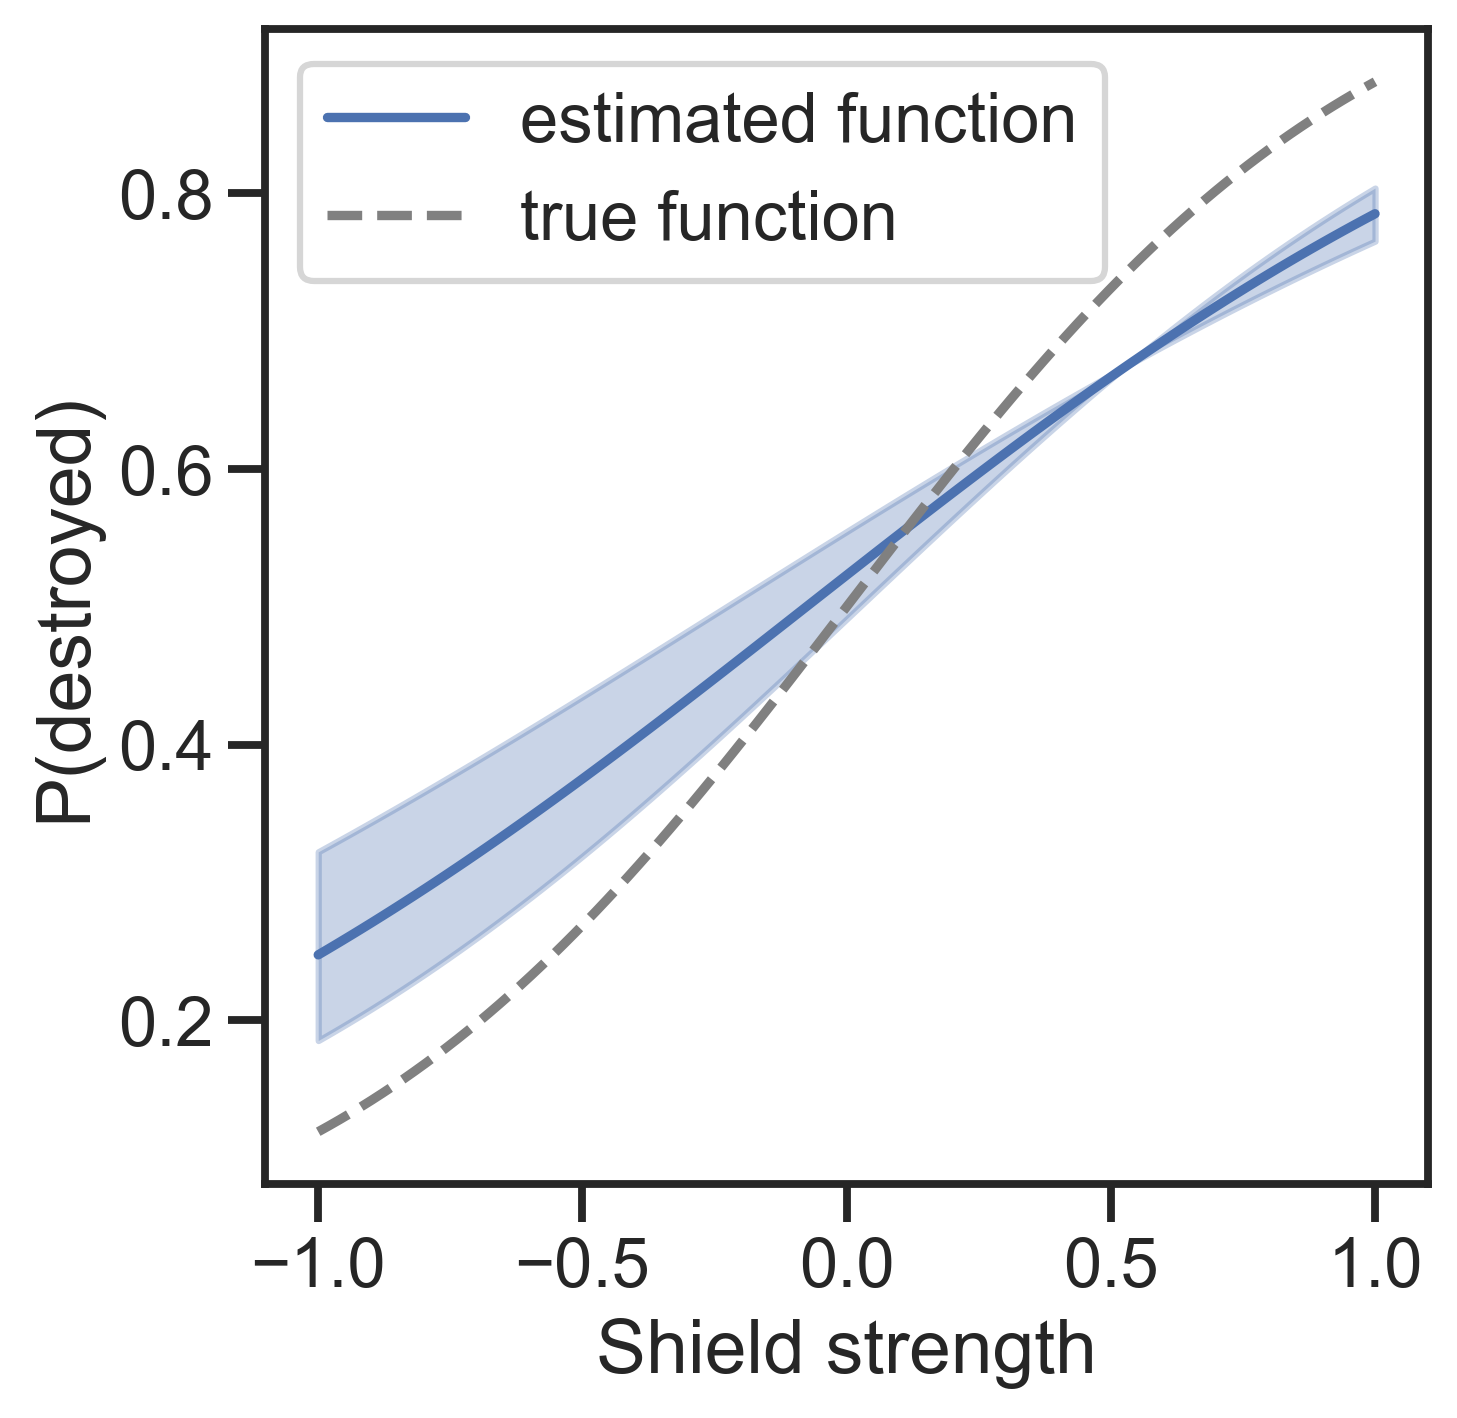

In [ ]:
# select beta for each subject at max t
max_beta = df_param[(df_param.t == df_param.t.max()) & (df_param.param == 'beta')].value.mean()
max_alpha = df_param[(df_param.t == df_param.t.max()) & (df_param.param == 'alpha')].value.mean()
std_beta = df_param[(df_param.t == df_param.t.max()) & (df_param.param == 'beta')].value.std()
std_alpha = df_param[(df_param.t == df_param.t.max()) & (df_param.param == 'alpha')].value.std()

plt.figure(figsize=(5, 5))
sns.set_context('talk')
# plot the sigmoid function with the max beta and alpha
x = np.linspace(-1, 1, 100)
y = 1 / (1 + np.exp(-max_beta*  x + max_alpha))
plt.plot(x, y, label='estimated function')
y_fill_up = 1 / (1 + np.exp(-(max_beta+std_beta)*  x + (max_alpha + std_alpha)))
y_fill_down = 1 / (1 + np.exp(-(max_beta-std_beta)*  x + (max_alpha - std_alpha)))
plt.fill_between(x, y_fill_up, y_fill_down, alpha=.3, color='C0', label='uncertainty')
# add the std 
plt.plot(x, 1 / (1 + np.exp(-2*x)), label='true function', color='grey', linestyle='--')
# plt.plot(np.linspace(-1, 1, 9), empirical_fn, label='empirical function', alpha=.1)
plt.legend()
plt.xlabel('Shield strength')
plt.ylabel('P(destroyed)')

handles, labels = plt.gca().get_legend_handles_labels()

handles = [handles[0], handles[2]]
labels = [labels[0], labels[2]]

plt.legend(handles, labels, loc='upper left')

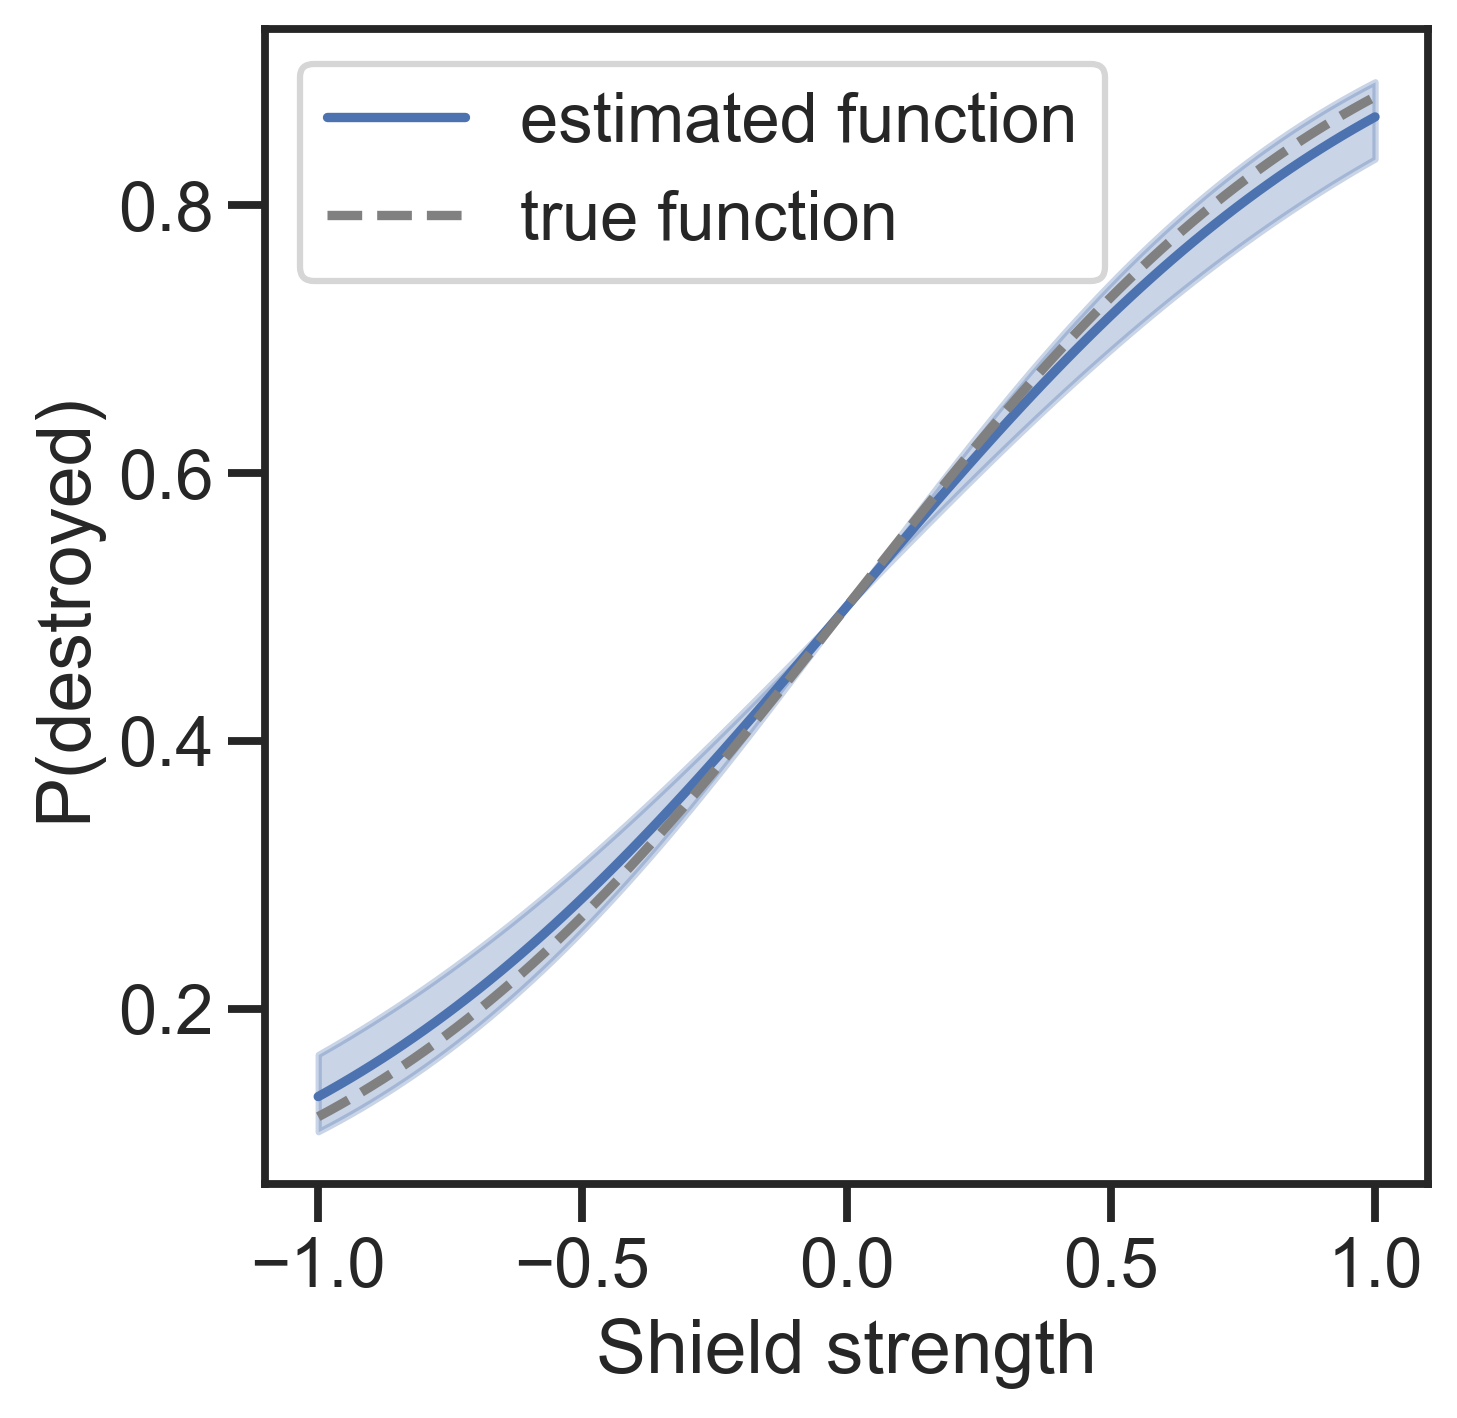

In [ ]:
# select beta for each subject at max t
max_beta = df_param[(df_param.t == df_param.t.max()) & (df_param.param == 'beta')].value.mean()
# max_alpha = df_param[(df_param.t == df_param.t.max()) & (df_param.param == 'alpha')].value.mean()
std_beta = df_param[(df_param.t == df_param.t.max()) & (df_param.param == 'beta')].value.std()
# std_alpha = df_param[(df_param.t == df_param.t.max()) & (df_param.param == 'alpha')].value.std()

plt.figure(figsize=(5, 5))
sns.set_context('talk')
# plot the sigmoid function with the max beta and alpha
x = np.linspace(-1, 1, 100)
y = 1 / (1 + np.exp(-max_beta*  x))
plt.plot(x, y, label='estimated function')
y_fill_up = 1 / (1 + np.exp(-(max_beta+std_beta)*  x))
y_fill_down = 1 / (1 + np.exp(-(max_beta-std_beta)*  x))
plt.fill_between(x, y_fill_up, y_fill_down, alpha=.3, color='C0', label='uncertainty')
# add the std 
plt.plot(x, 1 / (1 + np.exp(-2*x)), label='true function', color='grey', linestyle='--')
# plt.plot(np.linspace(-1, 1, 9), empirical_fn, label='empirical function', alpha=.1)
plt.legend()
plt.xlabel('Shield strength')
plt.ylabel('P(destroyed)')

handles, labels = plt.gca().get_legend_handles_labels()

handles = [handles[0], handles[2]]
labels = [labels[0], labels[2]]

plt.legend(handles, labels, loc='upper left')

# SIMULATE